# Distributed Deep Learning-Based Urdu OCR & Restoration System

**Datasets:** MMU-OCR-21 (Printed Nastaleeq) · NUST-UHWR (Handwritten Urdu)

---

# Phase 1 — Data Preprocessing & Synthetic Degradation

**Objectives:**
1. Standardise all images (uniform height, grayscale, aspect-ratio-preserving resize + padding)
2. Build a stochastic synthetic degradation pipeline (blur, noise, contrast, skew)
3. Split data into Train (70%) / Val (15%) / Test (15%) with zero data leakage
4. Visual unit tests — side-by-side grids of clean vs. degraded

## 1.0 — Environment Setup & GPU Check

In [1]:
import os, sys, random, warnings
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import torch
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
load_dotenv()

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# GPU check
print(f"CUDA available : {torch.cuda.is_available()}")
print(f"GPU count      : {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"GPU name       : {torch.cuda.get_device_name(0)}")

CUDA available : True
GPU count      : 1
GPU name       : NVIDIA GeForce RTX 3070 Laptop GPU


In [2]:
# Dataset root from .env
DATASET_ROOT = os.getenv("DATASET_ROOT", "V:\\")
print(f"DATASET_ROOT = {DATASET_ROOT}")
print(f"MMU-OCR-21 exists: {os.path.isdir(os.path.join(DATASET_ROOT, 'MMU-OCR-21'))}")
print(f"UHWR exists      : {os.path.isdir(os.path.join(DATASET_ROOT, 'UHWR'))}")

DATASET_ROOT = V:\
MMU-OCR-21 exists: True
UHWR exists      : True


## 1.1 — Dataset Discovery

Load image paths and ground-truth labels from both datasets using the helpers in `preprocessing.py`.

In [3]:
from preprocessing import discover_mmu_ocr21, discover_uhwr

# Discover MMU-OCR-21 (TextLines level — full Nastaleeq lines)
mmu_records = discover_mmu_ocr21(DATASET_ROOT, level="TextLines")
print(f"MMU-OCR-21 records: {len(mmu_records)}")

# Discover UHWR
uhwr_records = discover_uhwr(DATASET_ROOT)
print(f"UHWR records      : {len(uhwr_records)}")

# Combined
all_records = mmu_records + uhwr_records
print(f"Total records     : {len(all_records)}")

MMU-OCR-21 records: 100541
UHWR records      : 10602
Total records     : 111143


In [4]:
# Quick peek at a few records
for r in all_records[:3]:
    print(r)
print("...")
for r in all_records[-3:]:
    print(r)

{'image_path': 'V:\\MMU-OCR-21\\TextLines\\SentenceImages\\Nastaleeq\\Size_11\\Batch_0\\Sentence_0.jpg', 'label': 'آج سندھ بے حال ہے', 'source': 'MMU-OCR-21', 'font': 'Nastaleeq'}
{'image_path': 'V:\\MMU-OCR-21\\TextLines\\SentenceImages\\Nastaleeq\\Size_11\\Batch_0\\Sentence_1.jpg', 'label': 'فورسز نے فضا سے فضا', 'source': 'MMU-OCR-21', 'font': 'Nastaleeq'}
{'image_path': 'V:\\MMU-OCR-21\\TextLines\\SentenceImages\\Nastaleeq\\Size_11\\Batch_0\\Sentence_10.jpg', 'label': '3 کروڑ روپے لیے', 'source': 'MMU-OCR-21', 'font': 'Nastaleeq'}
...
{'image_path': 'V:\\UHWR\\Dataset\\images\\10603.jpg', 'label': 'وایک ایسے مسیحا کے منتظر ہیں جو آکر اس پسے ہوئے طبقے', 'source': 'UHWR'}
{'image_path': 'V:\\UHWR\\Dataset\\images\\10604.jpg', 'label': 'معاشی ناہمواریوں اور غیر مناسب سماجی رویوں کی وجہ سے', 'source': 'UHWR'}
{'image_path': 'V:\\UHWR\\Dataset\\images\\10605.jpg', 'label': 'وہ معاشی تعلقات بڑھانے کے خواہشمند ہیں تو وہاں بھارت کے علاوہ بعض دیگر ممالک', 'source': 'UHWR'}


## 1.2 — Image Standardisation

Every image is:
- Converted to **grayscale**
- Resized to a uniform **target height** (128 px) while preserving aspect ratio
- Padded (left-side, for RTL Urdu) to a fixed **target width** (512 px)

Raw shape: (32, 128, 4)
Standardised shape: (128, 2048)


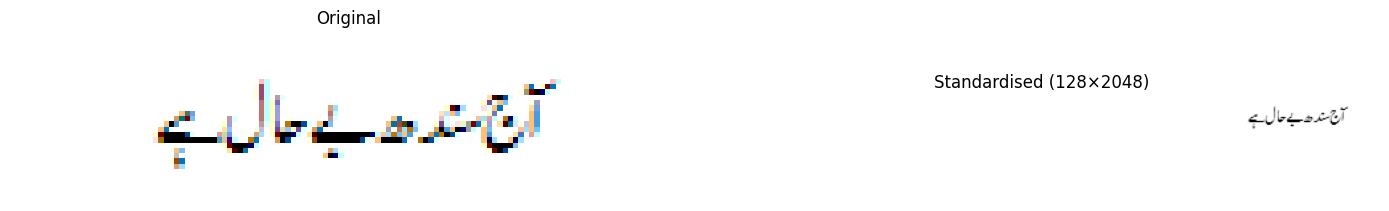

In [5]:
from preprocessing import standardize_and_pad, standardize_and_pad

TARGET_HEIGHT = 128
TARGET_WIDTH  = 2048

# Demo on a sample image
sample_path = all_records[0]["image_path"]
raw = cv2.imread(sample_path, cv2.IMREAD_UNCHANGED)
print(f"Raw shape: {raw.shape}")

std = standardize_and_pad(raw, TARGET_HEIGHT, TARGET_WIDTH)
print(f"Standardised shape: {std.shape}")

fig, axes = plt.subplots(1, 2, figsize=(14, 3))
axes[0].imshow(cv2.cvtColor(raw, cv2.COLOR_BGR2RGB) if len(raw.shape)==3 else raw, cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(std, cmap='gray')
axes[1].set_title(f'Standardised ({TARGET_HEIGHT}×{TARGET_WIDTH})')
for ax in axes: ax.axis('off')
plt.tight_layout()


## 1.3 — Synthetic Degradation Pipeline

Each clean image is stochastically degraded with a random combination of:
- **Gaussian Blur** (70% chance)
- **Gaussian or Salt-and-Pepper Noise** (80% chance)
- **Low Contrast / Faded Text** (50% chance)
- **Affine Skew** (40% chance)

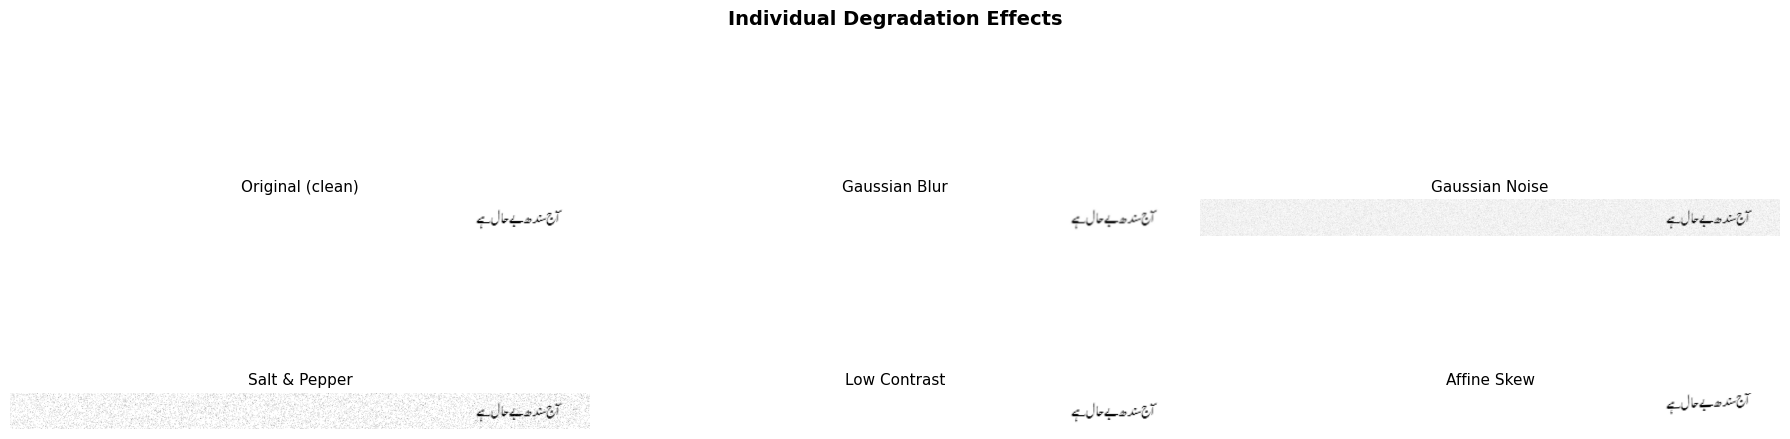

In [6]:
from preprocessing import (
    apply_gaussian_blur,
    apply_gaussian_noise,
    apply_salt_pepper_noise,
    apply_low_contrast,
    apply_affine_skew,
    degrade_image,
)

# Show individual degradation effects
clean = standardize_and_pad(raw, TARGET_HEIGHT, TARGET_WIDTH)

degradations = {
    "Original (clean)": clean,
    "Gaussian Blur":    apply_gaussian_blur(clean),
    "Gaussian Noise":   apply_gaussian_noise(clean),
    "Salt & Pepper":    apply_salt_pepper_noise(clean),
    "Low Contrast":     apply_low_contrast(clean),
    "Affine Skew":      apply_affine_skew(clean),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 6))
for ax, (title, img) in zip(axes.flat, degradations.items()):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=11)
    ax.axis('off')
plt.suptitle('Individual Degradation Effects', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

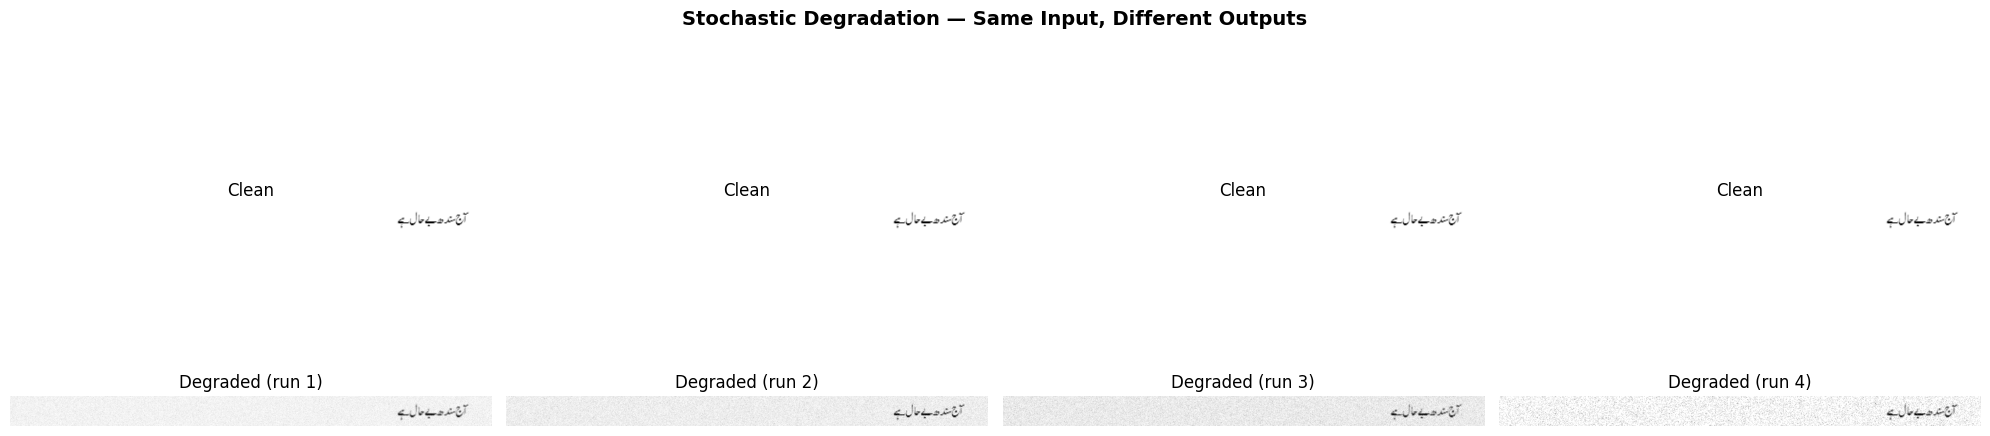

In [7]:
# Show the combined stochastic degradation applied multiple times
fig, axes = plt.subplots(2, 4, figsize=(20, 6))
for i in range(4):
    axes[0, i].imshow(clean, cmap='gray')
    axes[0, i].set_title('Clean')
    axes[0, i].axis('off')

    degraded = degrade_image(clean)
    axes[1, i].imshow(degraded, cmap='gray')
    axes[1, i].set_title(f'Degraded (run {i+1})')
    axes[1, i].axis('off')

plt.suptitle('Stochastic Degradation — Same Input, Different Outputs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 1.4 — Data Splitting (70 / 15 / 15)

We split at the **image level** (not pixel level), ensuring zero data leakage between train, val, and test.

In [8]:
from preprocessing import split_dataset, assert_no_data_leakage

train_records, val_records, test_records = split_dataset(
    all_records, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15, seed=SEED
)

total = len(all_records)
print(f"Train : {len(train_records):>6}  ({len(train_records)/total:.1%})")
print(f"Val   : {len(val_records):>6}  ({len(val_records)/total:.1%})")
print(f"Test  : {len(test_records):>6}  ({len(test_records)/total:.1%})")
print(f"Total : {total:>6}")

Train :  77800  (70.0%)
Val   :  16671  (15.0%)
Test  :  16672  (15.0%)
Total : 111143


In [9]:
# Source distribution per split
for name, recs in [("Train", train_records), ("Val", val_records), ("Test", test_records)]:
    sources = pd.Series([r["source"] for r in recs]).value_counts()
    print(f"\n{name} split source distribution:")
    print(sources.to_string())


Train split source distribution:
MMU-OCR-21    70268
UHWR           7532

Val split source distribution:
MMU-OCR-21    15114
UHWR           1557

Test split source distribution:
MMU-OCR-21    15159
UHWR           1513


## 1.5 — Data Leakage Assertion

Verify that **no image path** appears in more than one split.

In [10]:
assert_no_data_leakage(train_records, val_records, test_records)
print("All assertions passed — splits are clean.")

✓ No data leakage detected. Train=77800, Val=16671, Test=16672
All assertions passed — splits are clean.


## 1.6 — Visual Unit Tests: Clean vs. Degraded Grids

Side-by-side comparison of original (standardised) images and their synthetically degraded counterparts.

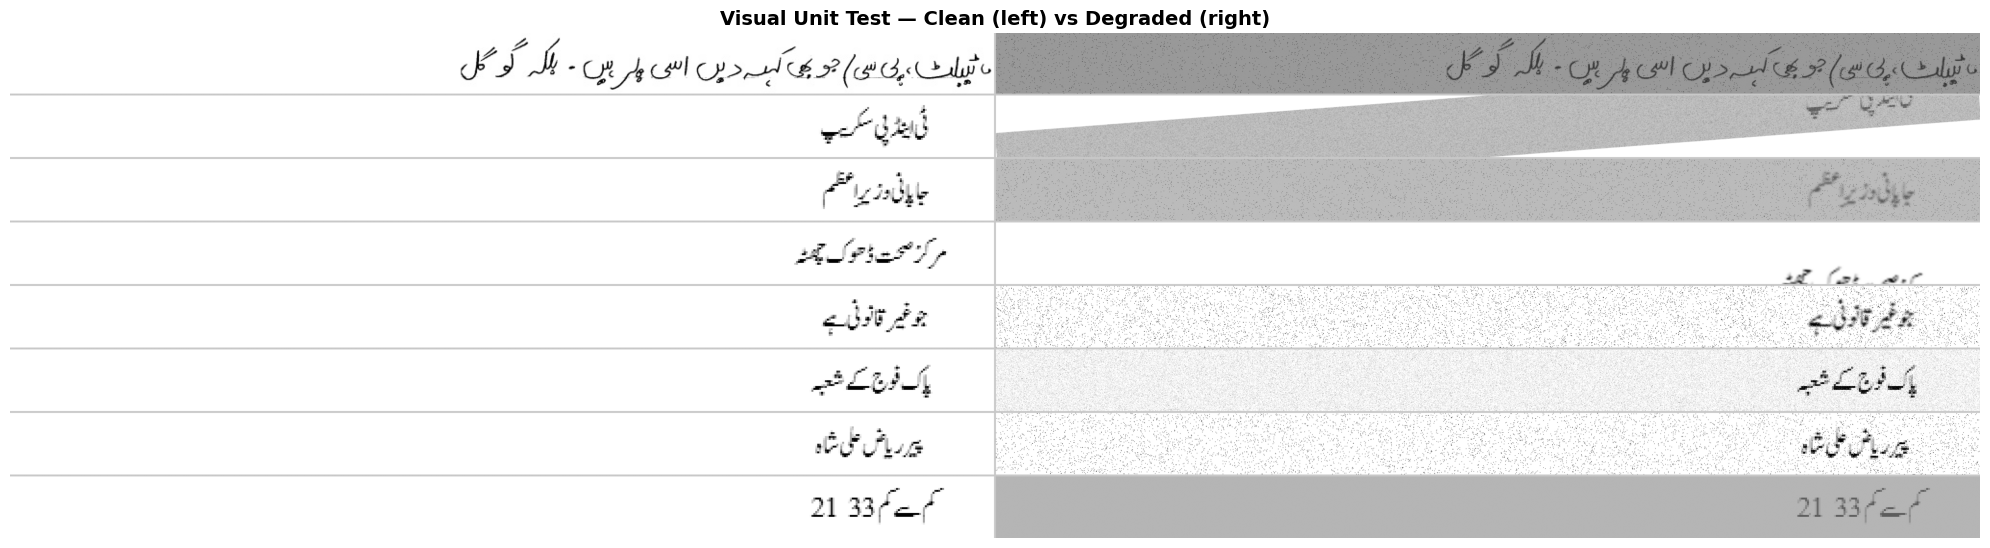

In [11]:
from preprocessing import make_comparison_grid

N_SAMPLES = 8  # number of rows in the grid

# Pick random samples from training set
rng = random.Random(SEED)
sample_indices = rng.sample(range(len(train_records)), min(N_SAMPLES, len(train_records)))

clean_imgs = []
degraded_imgs = []

for idx in sample_indices:
    rec = train_records[idx]
    img = cv2.imread(rec["image_path"], cv2.IMREAD_UNCHANGED)
    if img is None:
        continue
    c = standardize_and_pad(img, TARGET_HEIGHT, TARGET_WIDTH)
    d = degrade_image(c)
    clean_imgs.append(c)
    degraded_imgs.append(d)

grid = make_comparison_grid(clean_imgs, degraded_imgs, n=N_SAMPLES,
                            target_h=TARGET_HEIGHT, target_w=TARGET_WIDTH)

plt.figure(figsize=(20, N_SAMPLES * 2.5))
plt.imshow(grid, cmap='gray')
plt.title('Visual Unit Test — Clean (left) vs Degraded (right)', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## 1.7 — Multi-Source Visual Comparison

Show samples from **each dataset** separately so we can verify per-source quality.

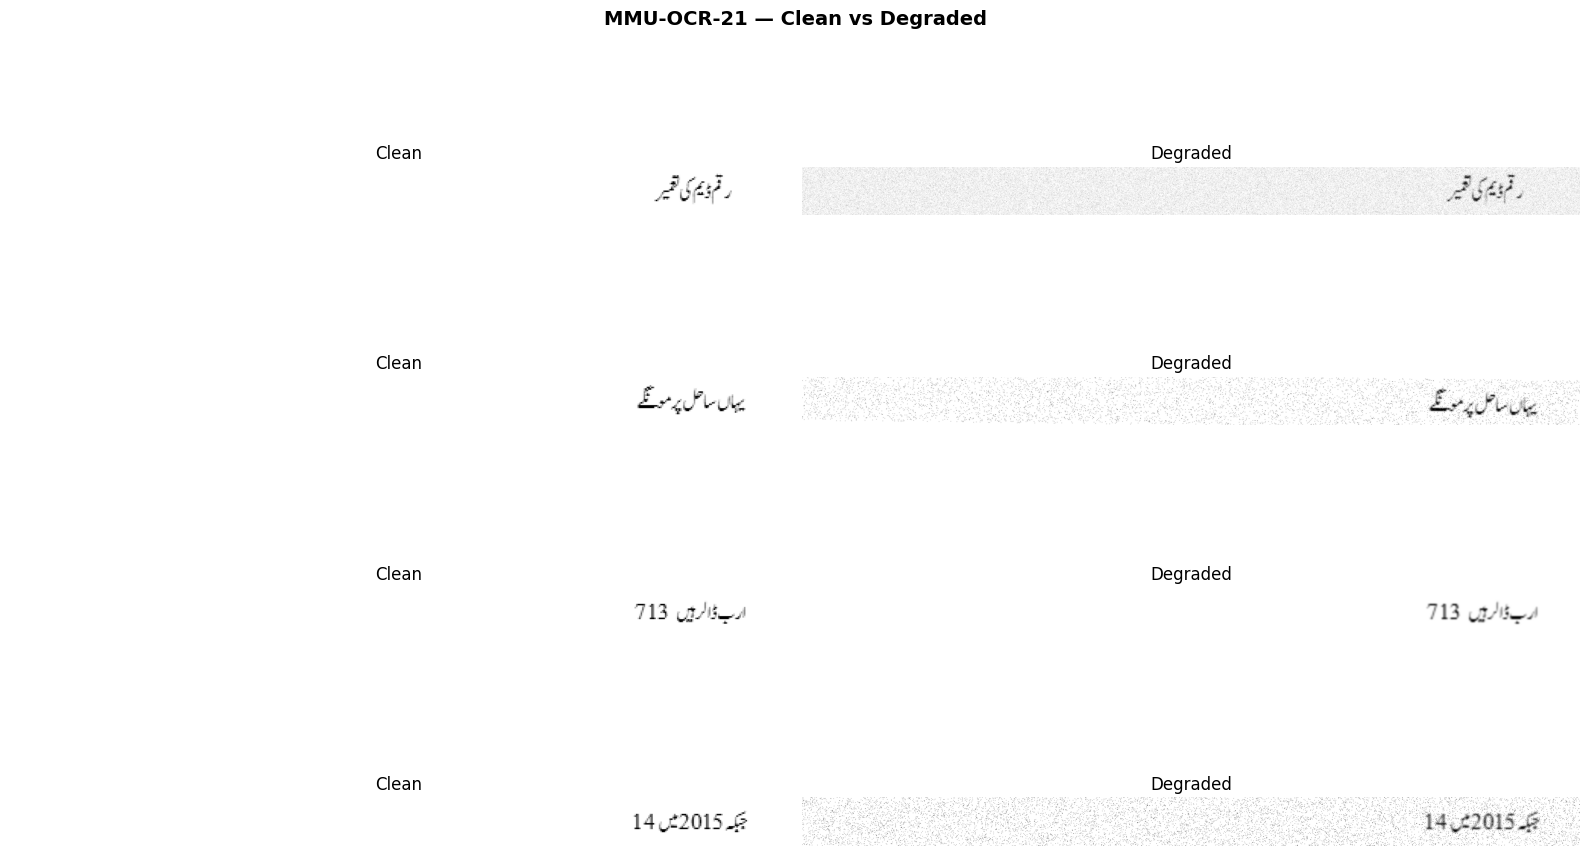

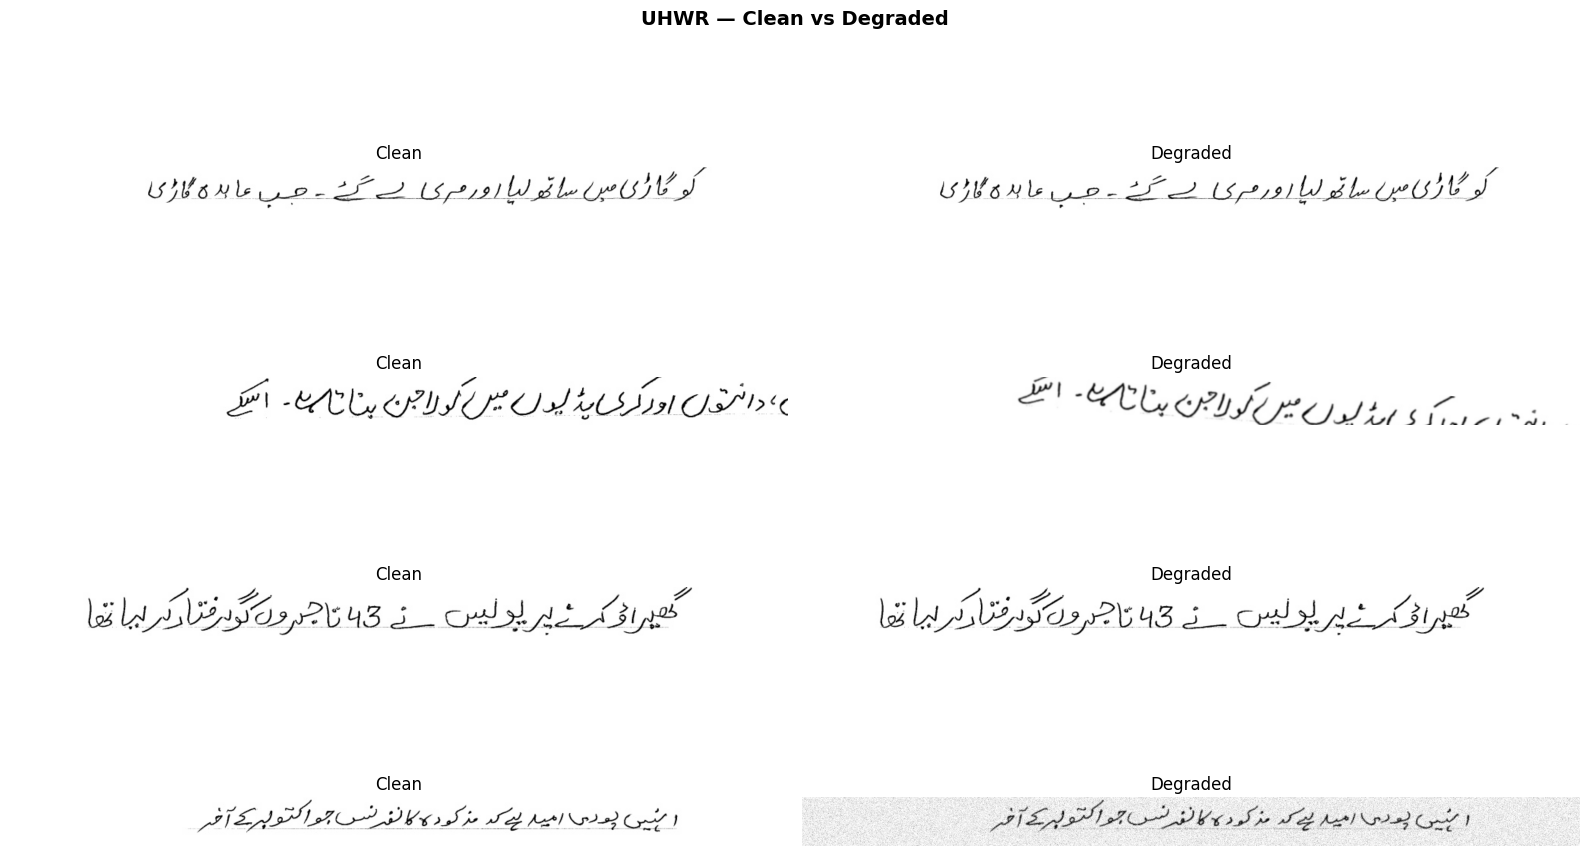

In [12]:
for source_name in ["MMU-OCR-21", "UHWR"]:
    source_recs = [r for r in train_records if r["source"] == source_name]
    if not source_recs:
        print(f"No records for {source_name}, skipping.")
        continue

    sample_idx = rng.sample(range(len(source_recs)), min(4, len(source_recs)))
    fig, axes = plt.subplots(len(sample_idx), 2, figsize=(16, len(sample_idx) * 2.5))
    if len(sample_idx) == 1:
        axes = axes[np.newaxis, :]

    for i, si in enumerate(sample_idx):
        img = cv2.imread(source_recs[si]["image_path"], cv2.IMREAD_UNCHANGED)
        if img is None:
            continue
        c = standardize_and_pad(img, TARGET_HEIGHT, TARGET_WIDTH)
        d = degrade_image(c)
        axes[i, 0].imshow(c, cmap='gray'); axes[i, 0].set_title('Clean'); axes[i, 0].axis('off')
        axes[i, 1].imshow(d, cmap='gray'); axes[i, 1].set_title('Degraded'); axes[i, 1].axis('off')

    plt.suptitle(f'{source_name} — Clean vs Degraded', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 1.8 — Summary Statistics

Sampled 500 images for dimension stats
Height — min: 32, max: 64, mean: 34, median: 32
Width  — min: 128, max: 1844, mean: 186, median: 128


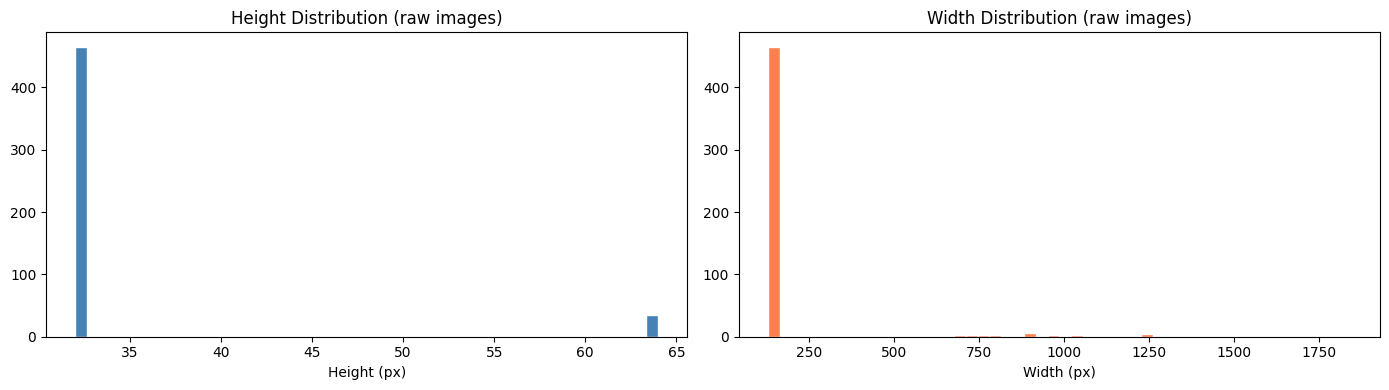

In [13]:
# Collect image dimension stats from a random subset
stat_sample = rng.sample(all_records, min(500, len(all_records)))
heights, widths = [], []
for rec in stat_sample:
    img = cv2.imread(rec["image_path"], cv2.IMREAD_UNCHANGED)
    if img is not None:
        h, w = img.shape[:2]
        heights.append(h)
        widths.append(w)

print(f"Sampled {len(heights)} images for dimension stats")
print(f"Height — min: {min(heights)}, max: {max(heights)}, "
      f"mean: {np.mean(heights):.0f}, median: {np.median(heights):.0f}")
print(f"Width  — min: {min(widths)}, max: {max(widths)}, "
      f"mean: {np.mean(widths):.0f}, median: {np.median(widths):.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(heights, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Height Distribution (raw images)')
axes[0].set_xlabel('Height (px)')
axes[1].hist(widths, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Width Distribution (raw images)')
axes[1].set_xlabel('Width (px)')
plt.tight_layout()
plt.show()

In [14]:
# Label availability
labelled = sum(1 for r in all_records if r["label"])
unlabelled = len(all_records) - labelled
print(f"With labels   : {labelled:>6}  ({labelled/len(all_records):.1%})")
print(f"Without labels: {unlabelled:>6}  ({unlabelled/len(all_records):.1%})")

With labels   : 111142  (100.0%)
Without labels:      1  (0.0%)


## 1.9 — Save Preprocessed Splits

Persist the split metadata (paths + labels) to CSV files for reproducible downstream use.

In [15]:
SPLITS_DIR = os.path.join(os.getcwd(), "splits")
os.makedirs(SPLITS_DIR, exist_ok=True)

for name, recs in [("train", train_records), ("val", val_records), ("test", test_records)]:
    df = pd.DataFrame(recs)
    path = os.path.join(SPLITS_DIR, f"{name}.csv")
    df.to_csv(path, index=False, encoding="utf-8")
    print(f"Saved {name}.csv — {len(df)} records")

print(f"\nSplit CSVs saved to: {SPLITS_DIR}")

Saved train.csv — 77800 records
Saved val.csv — 16671 records
Saved test.csv — 16672 records

Split CSVs saved to: e:\University\S6\DL\DLProject\splits


---
### Phase 1 ✅ Complete

**What was done:**
1. Discovered & loaded both MMU-OCR-21 and UHWR datasets
2. Standardised images to uniform height (128px) with aspect-ratio padding
3. Built a stochastic synthetic degradation pipeline (blur, noise, contrast, skew)
4. Split data 70/15/15 with verified zero data leakage
5. Generated visual unit-test grids (clean vs. degraded)
6. Saved split metadata to CSV for downstream phases

---
# Phase 2 — Image Restoration Model (SMP U-Net)

**Objective:** Train a U-Net to denoise and restore synthetically degraded images back to their clean state.

**Architecture:** `segmentation_models_pytorch` U-Net with ResNet-34 encoder (ImageNet pretrained)

**Key specs:**
- Input / Output: single-channel grayscale (`in_channels=1`, `classes=1`)
- Loss: MSE (pixel-level regression)
- Optimizer: Adam
- Evaluation: PSNR & SSIM

## 2.0 — Install SMP & Imports

In [16]:
# Install SMP if not already available
import segmentation_models_pytorch as smp
print(f'SMP version: {smp.__version__}')

# Phase 2 module imports
from datasets.restoration_dataset import RestorationDataset, get_dataloaders
from models.restoration_model import (
    build_restoration_model, RestorationTrainer,
    compute_psnr, compute_ssim, load_restoration_model
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

SMP version: 0.5.0
Device: cuda


## 2.1 — Dataset & DataLoaders

In [17]:
# Create DataLoaders from Phase 1 split CSVs
loaders = get_dataloaders(
    splits_dir='splits',
    target_height=TARGET_HEIGHT,
    target_width=TARGET_WIDTH,
    batch_size=8,
    num_workers=0,
)

for name, loader in loaders.items():
    print(f'{name:5s}: {len(loader.dataset):,} samples, {len(loader)} batches')

train: 77,800 samples, 9725 batches
val  : 16,671 samples, 2084 batches
test : 16,672 samples, 2084 batches


Degraded batch shape: torch.Size([8, 1, 128, 2048])
Clean batch shape:    torch.Size([8, 1, 128, 2048])


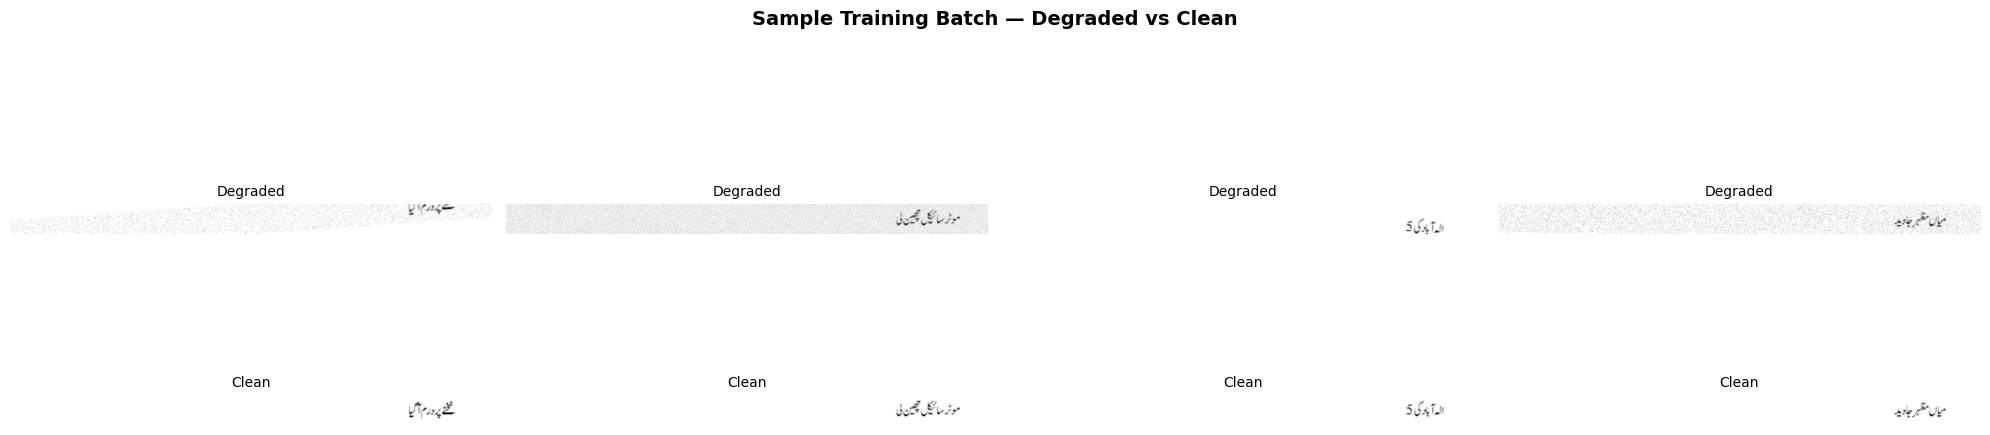

In [18]:
# Visualise a sample batch: degraded (top) vs clean (bottom)
sample_degraded, sample_clean = next(iter(loaders['train']))
print(f'Degraded batch shape: {sample_degraded.shape}')
print(f'Clean batch shape:    {sample_clean.shape}')

fig, axes = plt.subplots(2, 4, figsize=(20, 6))
for i in range(4):
    axes[0, i].imshow(sample_degraded[i].squeeze().numpy(), cmap='gray')
    axes[0, i].set_title('Degraded', fontsize=10)
    axes[0, i].axis('off')
    axes[1, i].imshow(sample_clean[i].squeeze().numpy(), cmap='gray')
    axes[1, i].set_title('Clean', fontsize=10)
    axes[1, i].axis('off')
fig.suptitle('Sample Training Batch — Degraded vs Clean', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.2 — Model Architecture

In [19]:
# Build the restoration model
restoration_model = build_restoration_model(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=1,
    classes=1,
)

# Verify forward pass shape
dummy = torch.randn(1, 1, TARGET_HEIGHT, TARGET_WIDTH).to(DEVICE)
restoration_model = restoration_model.to(DEVICE)
with torch.no_grad():
    out = restoration_model(dummy)
print(f'Input shape:  {dummy.shape}')
print(f'Output shape: {out.shape}')
assert dummy.shape == out.shape, 'Shape mismatch!'
print('✓ Forward pass verified — input and output shapes match')

# Parameter count
total_params = sum(p.numel() for p in restoration_model.parameters())
trainable = sum(p.numel() for p in restoration_model.parameters() if p.requires_grad)
print(f'Total params:     {total_params:,}')
print(f'Trainable params: {trainable:,}')

Input shape:  torch.Size([1, 1, 128, 2048])
Output shape: torch.Size([1, 1, 128, 2048])
✓ Forward pass verified — input and output shapes match
Total params:     24,430,097
Trainable params: 24,430,097


## 2.3 — Micro-Batch Overfit Test

Train on a tiny subset (8 images) for ~50 epochs to verify the network
can memorize the data and MSE loss approaches zero.

In [20]:
# Create a tiny dataset (8 samples) for the overfit sanity check
micro_loader = get_dataloaders(
    splits_dir='splits',
    target_height=TARGET_HEIGHT,
    target_width=TARGET_WIDTH,
    batch_size=8,
    num_workers=0,
    max_train_samples=8,
)['train']

# Use deterministic degradation so the same input is seen every epoch
micro_loader.dataset.deterministic = True

# Fresh model for this test
micro_model = build_restoration_model().to(DEVICE)
micro_trainer = RestorationTrainer(micro_model, DEVICE, lr=1e-3)

print('Micro-batch overfit test (8 images, 50 epochs):')
print('-' * 50)
micro_history = micro_trainer.fit(
    train_loader=micro_loader,
    val_loader=micro_loader,
    epochs=50,
    save_dir='checkpoints/micro_test',
    verbose=True,
)

Micro-batch overfit test (8 images, 50 epochs):
--------------------------------------------------
Epoch 1/50 | Train Loss: 0.198484 | Val Loss: 0.282118 | PSNR: 5.50 dB | SSIM: 0.5014 ★ | 1.1s
Epoch 2/50 | Train Loss: 0.171118 | Val Loss: 0.224724 | PSNR: 6.48 dB | SSIM: 0.3062 ★ | 0.8s
Epoch 3/50 | Train Loss: 0.144157 | Val Loss: 0.206058 | PSNR: 6.86 dB | SSIM: 0.3013 ★ | 0.8s
Epoch 4/50 | Train Loss: 0.122723 | Val Loss: 0.194588 | PSNR: 7.11 dB | SSIM: 0.2265 ★ | 0.8s
Epoch 5/50 | Train Loss: 0.101234 | Val Loss: 0.370008 | PSNR: 4.32 dB | SSIM: 0.1336 | 0.6s
Epoch 6/50 | Train Loss: 0.086246 | Val Loss: 0.077548 | PSNR: 11.10 dB | SSIM: 0.4028 ★ | 0.8s
Epoch 7/50 | Train Loss: 0.075184 | Val Loss: 0.040950 | PSNR: 13.88 dB | SSIM: 0.7094 ★ | 0.8s
Epoch 8/50 | Train Loss: 0.065991 | Val Loss: 0.030724 | PSNR: 15.13 dB | SSIM: 0.6937 ★ | 0.8s
Epoch 9/50 | Train Loss: 0.057861 | Val Loss: 0.030851 | PSNR: 15.11 dB | SSIM: 0.7084 | 0.6s
Epoch 10/50 | Train Loss: 0.051872 | Val Loss:

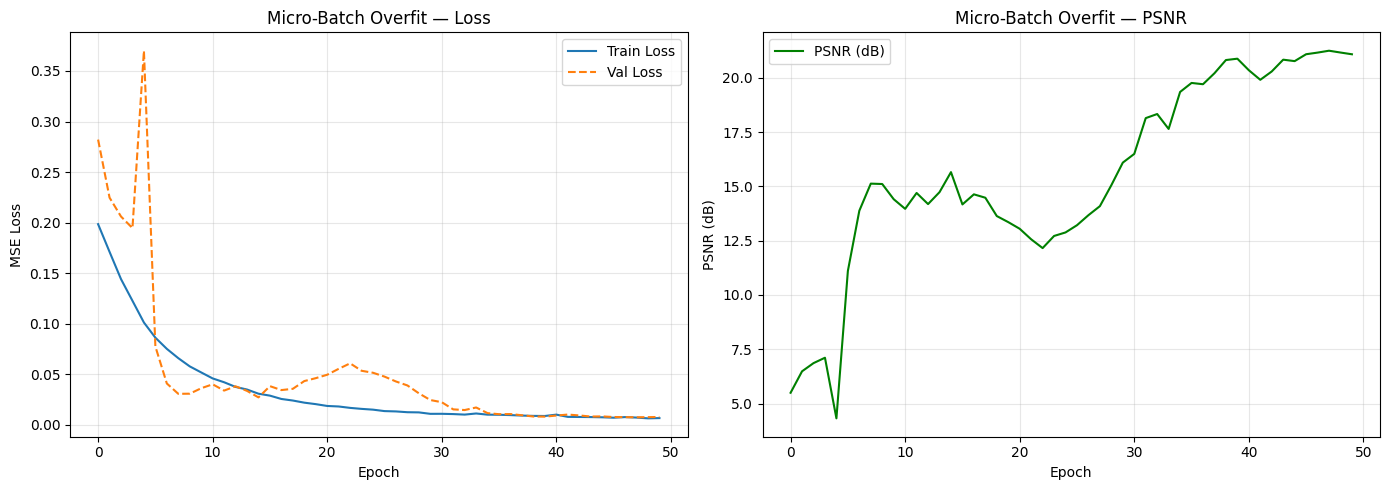


Final train loss: 0.006730
✓ Overfit test PASSED — model can memorize a micro-batch


In [21]:
# Plot the micro-batch overfit curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(micro_history['train_loss'], label='Train Loss')
ax1.plot(micro_history['val_loss'], label='Val Loss', linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.set_title('Micro-Batch Overfit — Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(micro_history['val_psnr'], label='PSNR (dB)', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('PSNR (dB)')
ax2.set_title('Micro-Batch Overfit — PSNR')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

final_loss = micro_history['train_loss'][-1]
print(f'\nFinal train loss: {final_loss:.6f}')
if final_loss < 0.01:
    print('✓ Overfit test PASSED — model can memorize a micro-batch')
else:
    print('⚠ Loss is still high — consider more epochs or check the pipeline')

## 2.4 — Full Training

In [22]:
# Full training with validation tracking
restoration_model = build_restoration_model(
    encoder_name='resnet34',
    encoder_weights='imagenet',
).to(DEVICE)

final_res_path = os.path.join('checkpoints', 'final_restoration_model.pth')
if os.path.exists(final_res_path):
    print('Found final Phase 2 model checkpoint. Resuming training from these weights...')
    restoration_model.load_state_dict(torch.load(final_res_path, map_location=DEVICE, weights_only=True))
else:
    print('No existing final checkpoint found. Starting training from scratch...')

trainer = RestorationTrainer(
    model=restoration_model,
    device=DEVICE,
    lr=1e-3,
    loss_fn='mse',
)

NUM_EPOCHS = 5  # adjust based on available compute time

print(f'\nTraining for {NUM_EPOCHS} epochs...')
print('=' * 70)
history = trainer.fit(
    train_loader=loaders['train'],
    val_loader=loaders['val'],
    epochs=NUM_EPOCHS,
    save_dir='checkpoints',
    verbose=True,
)


No existing final checkpoint found. Starting training from scratch...

Training for 5 epochs...
Epoch 1/5 | Train Loss: 0.002463 | Val Loss: 0.001076 | PSNR: 31.05 dB | SSIM: 0.9875 ★ | 3361.7s
Epoch 2/5 | Train Loss: 0.000931 | Val Loss: 0.000710 | PSNR: 33.34 dB | SSIM: 0.9915 ★ | 3280.1s
Epoch 3/5 | Train Loss: 0.000714 | Val Loss: 0.000819 | PSNR: 32.46 dB | SSIM: 0.9887 | 3283.3s
Epoch 4/5 | Train Loss: 0.000638 | Val Loss: 0.000568 | PSNR: 34.50 dB | SSIM: 0.9932 ★ | 3273.4s
Epoch 5/5 | Train Loss: 0.000584 | Val Loss: 0.000575 | PSNR: 34.78 dB | SSIM: 0.9930 | 3271.3s


NameError: name 'ocr_history' is not defined

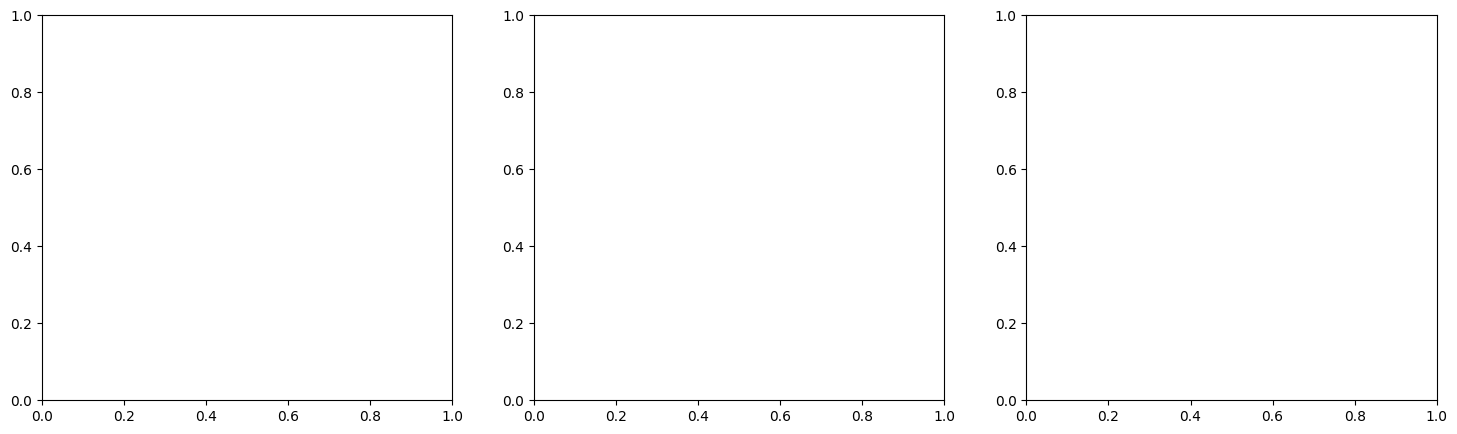

In [23]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(ocr_history['train_loss'], label='Train', marker='o')
axes[0].plot(ocr_history['val_loss'], label='Val', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('CE Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CER
axes[1].plot(ocr_history['val_cer'], label='Val CER', color='red', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('CER')
axes[1].set_title('Validation Character Error Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# WER
axes[2].plot(ocr_history['val_wer'], label='Val WER', color='orange', marker='o')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('WER')
axes[2].set_title('Validation Word Error Rate')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Phase 3 \u2014 OCR Model Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 2.5 — Test Set Evaluation (PSNR & SSIM)

In [24]:
# Load the best model and evaluate on test set
import os
best_path = os.path.join('checkpoints', 'best_restoration_model.pth')
if os.path.exists(best_path):
    best_model = load_restoration_model(best_path, DEVICE)
    print('Loaded best model from checkpoint')
else:
    best_model = restoration_model
    print('Using final training model (no best checkpoint found)')

test_trainer = RestorationTrainer(best_model, DEVICE)
test_metrics = test_trainer.validate(loaders['test'])

print(f'\n{"=" * 40}')
print(f'TEST SET RESULTS')
print(f'{"=" * 40}')
print(f'MSE Loss : {test_metrics["loss"]:.6f}')
print(f'PSNR     : {test_metrics["psnr"]:.2f} dB')
print(f'SSIM     : {test_metrics["ssim"]:.4f}')

Loaded best model from checkpoint

TEST SET RESULTS
MSE Loss : 0.000574
PSNR     : 34.52 dB
SSIM     : 0.9932


## 2.6 — Visual Results (Degraded → Restored → Clean)

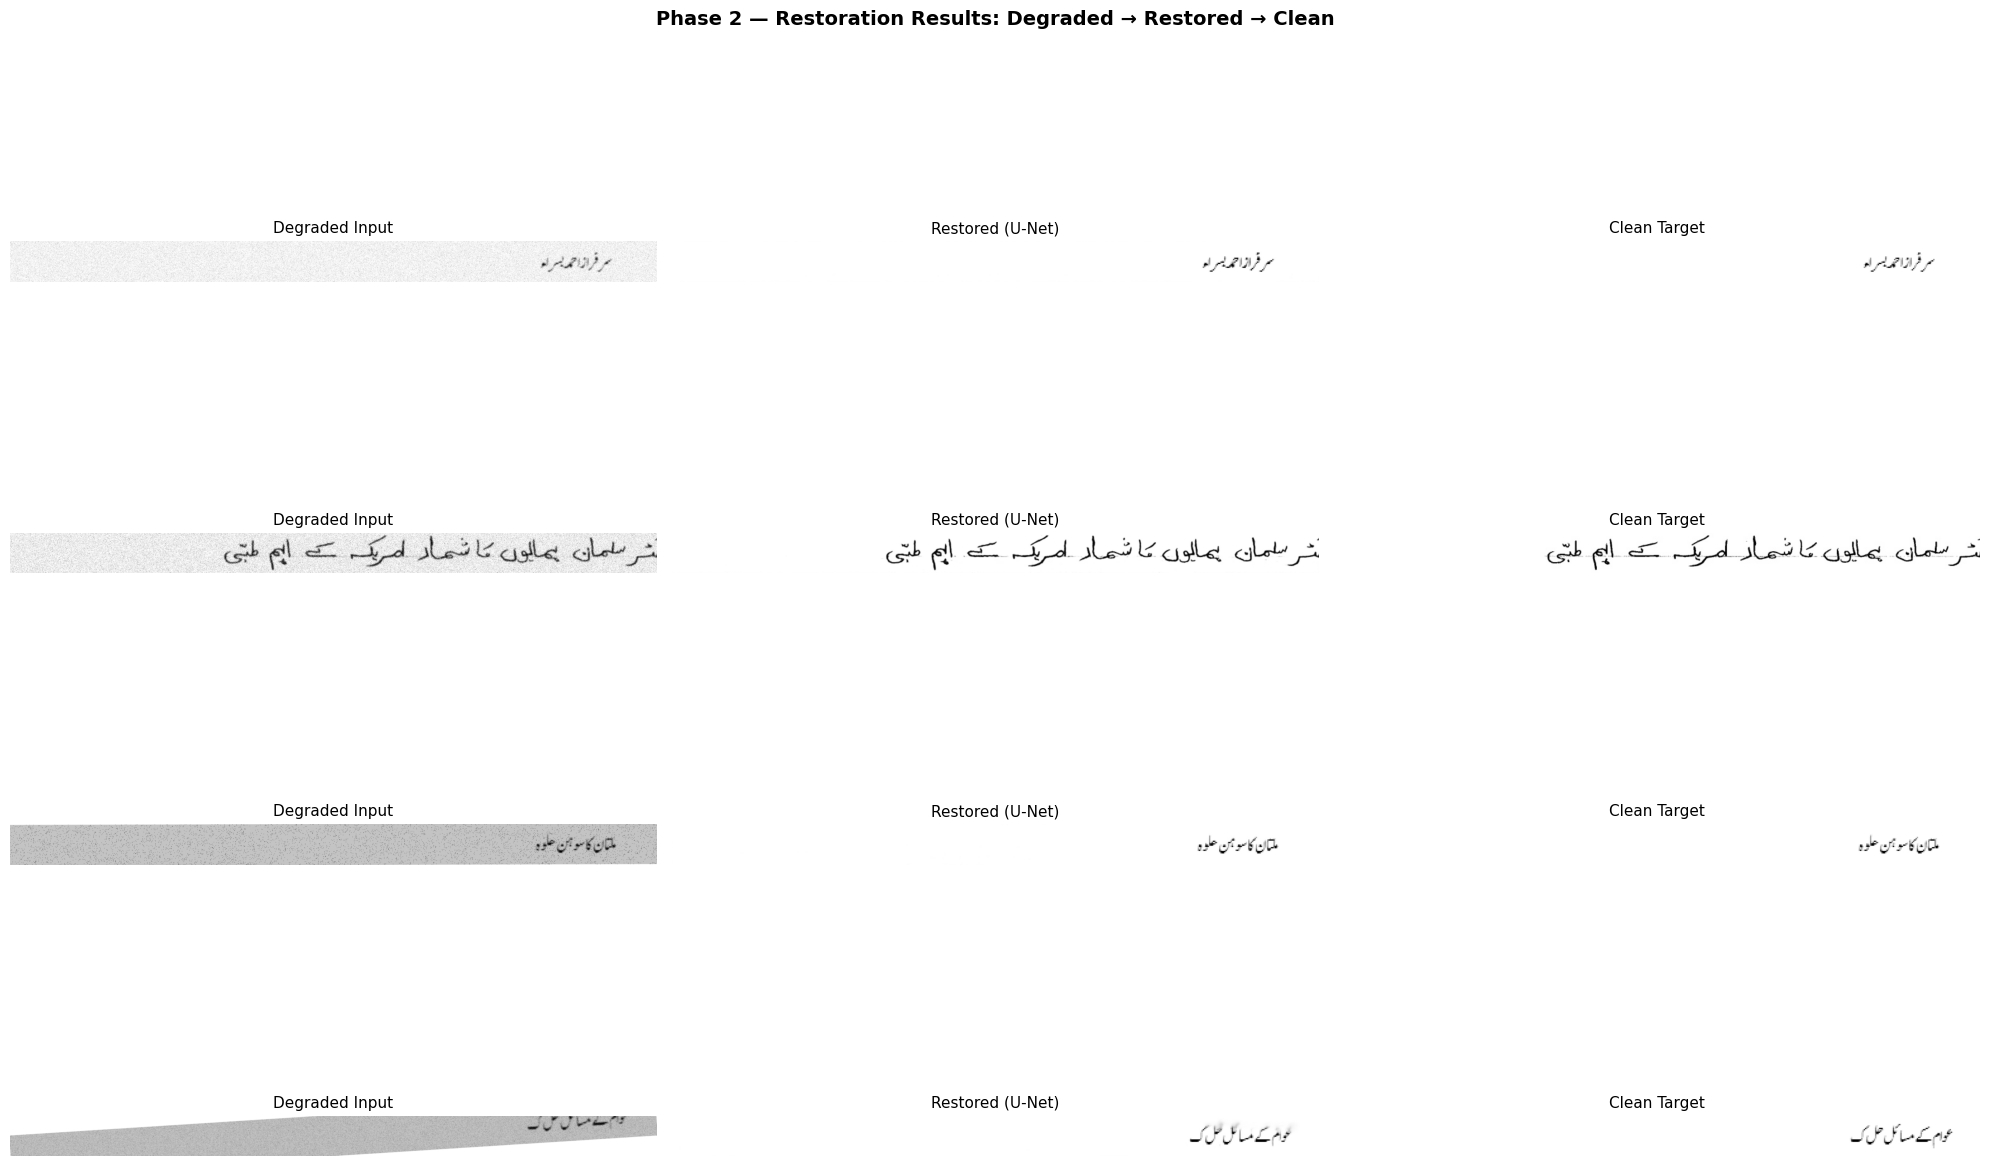

In [25]:
# Show side-by-side: Degraded | Restored | Clean
best_model.eval()
test_batch_deg, test_batch_clean = next(iter(loaders['test']))
test_batch_deg_gpu = test_batch_deg.to(DEVICE)

with torch.no_grad():
    test_batch_restored = best_model(test_batch_deg_gpu).cpu()

N_VIS = min(4, test_batch_deg.size(0))
fig, axes = plt.subplots(N_VIS, 3, figsize=(20, N_VIS * 3.5))
if N_VIS == 1:
    axes = axes[np.newaxis, :]

for i in range(N_VIS):
    axes[i, 0].imshow(test_batch_deg[i].squeeze().numpy(), cmap='gray')
    axes[i, 0].set_title('Degraded Input', fontsize=11)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(test_batch_restored[i].squeeze().numpy(), cmap='gray')
    axes[i, 1].set_title('Restored (U-Net)', fontsize=11)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(test_batch_clean[i].squeeze().numpy(), cmap='gray')
    axes[i, 2].set_title('Clean Target', fontsize=11)
    axes[i, 2].axis('off')

fig.suptitle('Phase 2 — Restoration Results: Degraded → Restored → Clean',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
### Phase 2 ✅ Complete

**What was done:**
1. Installed and configured `segmentation_models_pytorch` (SMP)
2. Built a U-Net with ResNet-34 encoder (ImageNet pretrained), 1-channel grayscale in/out
3. Created `RestorationDataset` with on-the-fly degradation (stochastic for training, deterministic for val/test)
4. Passed micro-batch overfit sanity test (MSE → 0 on 8 images)
5. Trained full model with validation tracking (loss, PSNR, SSIM)
6. Evaluated on held-out test set with PSNR & SSIM metrics
7. Visualised degraded → restored → clean results

---
# Phase 3 — Conv-Transformer Urdu OCR Sequence Model

**Objective:** Train a sequence-to-sequence model to recognise Urdu text from document images.

**Architecture:** CNN Backbone (7 blocks, LeakyReLU + BatchNorm) → Positional Encoding → Transformer (3 Enc + 3 Dec)

**Key specs:**
- `d_model=256`, `nhead=8`, `dim_feedforward=1024`
- Cross-Entropy Loss (NOT CTC)
- Adam (`lr=3e-4`, `betas=(0.9, 0.98)`, `eps=1e-9`)
- Beam Search with length penalty `alpha=0.7`

## 3.0 — Imports & Label Verification

In [26]:
# Phase 3 module imports
from models.vocab import Vocabulary, PAD_IDX, SOS_IDX, EOS_IDX
from models.ocr_model import ConvTransformerOCR, CNNBackbone, load_ocr_model
from models.ocr_trainer import OCRTrainer, compute_cer, compute_wer
from datasets.ocr_dataset import OCRDataset, get_ocr_dataloaders

# Verify labels are populated in splits
for split in ['train', 'val', 'test']:
    df = pd.read_csv(f'splits/{split}.csv')
    has_label = df['label'].notna() & (df['label'].astype(str).str.strip() != '')
    print(f'{split:5s}: {len(df):,} total, {has_label.sum():,} with labels')

train: 77,800 total, 77,799 with labels
val  : 16,671 total, 16,671 with labels
test : 16,672 total, 16,672 with labels


## 3.1 — Vocabulary

In [27]:
# Build vocabulary from training labels
train_df = pd.read_csv('splits/train.csv')
train_labels = train_df['label'].dropna().astype(str).tolist()

vocab = Vocabulary()
chars_file = os.path.join(DATASET_ROOT, 'UHWR', 'chars.txt')
vocab.build_from_texts(train_labels, chars_file=chars_file)

print(f'Vocabulary size: {vocab.size}')
print(f'Special tokens: PAD={PAD_IDX}, SOS={SOS_IDX}, EOS={EOS_IDX}')

# Save for deployment
os.makedirs('checkpoints', exist_ok=True)
vocab.save('checkpoints/vocab.json')
print('Saved vocabulary to checkpoints/vocab.json')

# Test encode/decode
sample_label = train_labels[0]
encoded = vocab.encode(sample_label)
decoded = vocab.decode(encoded)
print(f'\nSample: {sample_label}')
print(f'Encoded: {encoded[:20]}...')
print(f'Decoded: {decoded}')

Vocabulary size: 173
Special tokens: PAD=0, SOS=1, EOS=2
Saved vocabulary to checkpoints/vocab.json

Sample: مزید کام کرنا ہوگا
Encoded: [1, 121, 108, 154, 105, 4, 147, 97, 121, 4, 147, 107, 122, 97, 4, 151, 124, 148, 97, 2]...
Decoded: مزید کام کرنا ہوگا


## 3.2 — OCR Dataset & DataLoaders

In [28]:
# Create OCR DataLoaders (batch_size=16 per spec)
# Adding source-weighted config for UHWR
ocr_loaders = get_ocr_dataloaders(
    vocab=vocab,
    splits_dir='splits',
    target_height=TARGET_HEIGHT,
    target_width=TARGET_WIDTH,
    batch_size=16,
    num_workers=0,
    source_weights={'UHWR': 3.0, 'MMU-OCR-21': 1.0}
)

for name, loader in ocr_loaders.items():
    print(f'{name:5s}: {len(loader.dataset):,} samples, {len(loader)} batches')


train: 77,799 samples, 4863 batches
val  : 16,671 samples, 1042 batches
test : 16,672 samples, 1042 batches


Image batch:  torch.Size([16, 1, 128, 2048])
Label batch:  torch.Size([16, 21])
Label lengths: [15, 18, 16, 19, 19, 16, 21, 20]


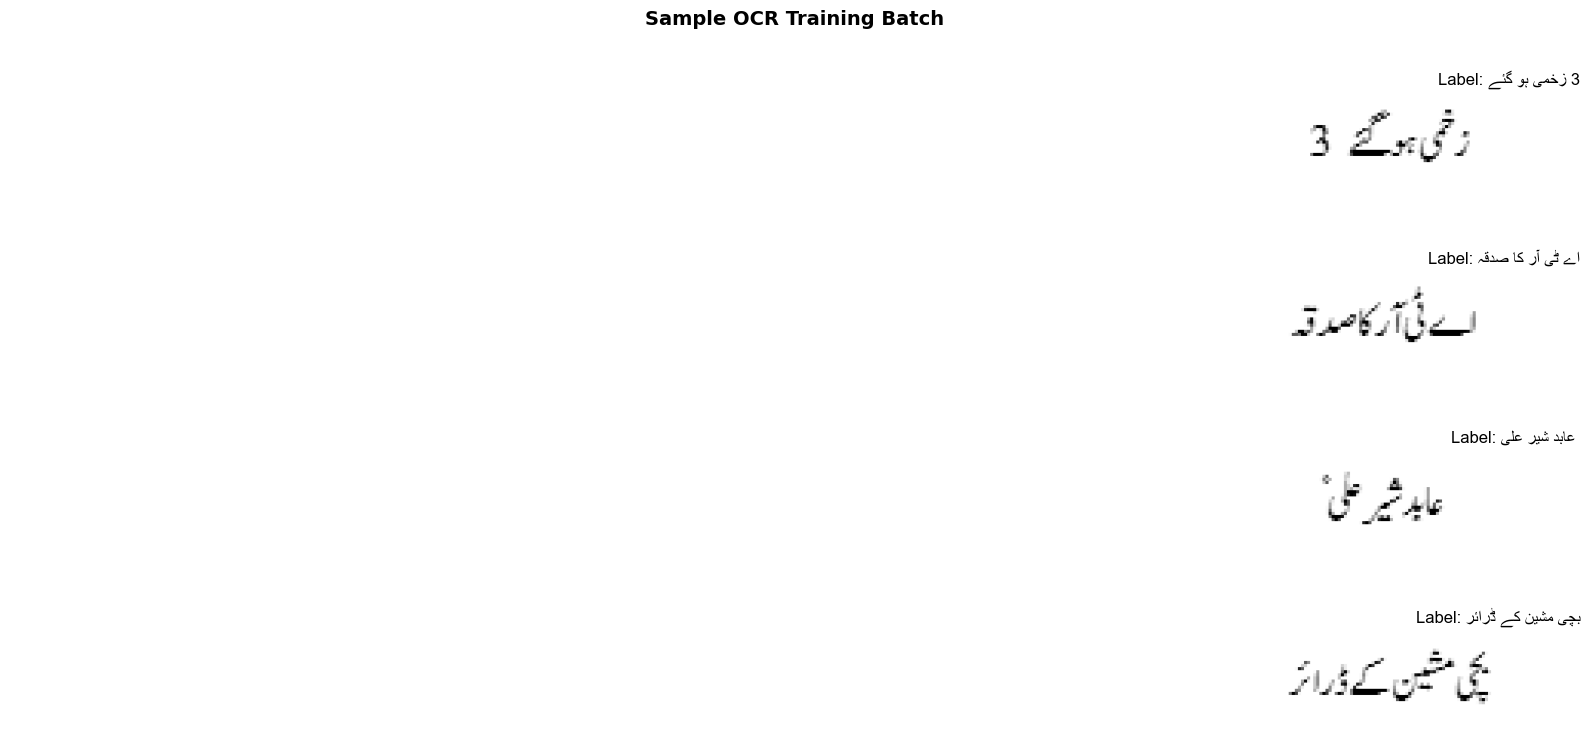

In [29]:
# Visualise a sample OCR batch
import arabic_reshaper
from bidi.algorithm import get_display

sample_imgs, sample_labels, sample_lens, _ = next(iter(ocr_loaders['train']))
print(f'Image batch:  {sample_imgs.shape}')
print(f'Label batch:  {sample_labels.shape}')
print(f'Label lengths: {sample_lens[:8].tolist()}')

fig, axes = plt.subplots(4, 1, figsize=(16, 8))
for i in range(4):
    axes[i].imshow(sample_imgs[i].squeeze().numpy(), cmap='gray')
    label_text = vocab.decode(sample_labels[i].tolist())
    
    # Reshape and reverse string for RTL display in matplotlib
    reshaped_text = arabic_reshaper.reshape(label_text)
    bidi_text = get_display(reshaped_text)
    
    axes[i].set_title(f'Label: {bidi_text}', fontsize=12, loc='right', fontfamily='Arial')
    axes[i].axis('off')
fig.suptitle('Sample OCR Training Batch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 3.3 — Model Architecture

In [30]:
# Build the Conv-Transformer OCR model
ocr_model = ConvTransformerOCR(
    vocab_size=vocab.size,
    d_model=256,
    nhead=8,
    num_encoder_layers=3,
    num_decoder_layers=3,
    dim_feedforward=1024,
    dropout=0.1,
).to(DEVICE)

total_params = sum(p.numel() for p in ocr_model.parameters())
trainable = sum(p.numel() for p in ocr_model.parameters() if p.requires_grad)
print(f'Total params:     {total_params:,}')
print(f'Trainable params: {trainable:,}')

Total params:     7,337,197
Trainable params: 7,337,197


## 3.4 — Shape Alignment Test

Verify CNN output feeds correctly into the Transformer encoder.

In [31]:
# CNN shape verification
dummy_img = torch.randn(1, 1, TARGET_HEIGHT, TARGET_WIDTH).to(DEVICE)
with torch.no_grad():
    cnn_out = ocr_model.cnn(dummy_img)
    memory = ocr_model.encode(dummy_img)

seq_len = cnn_out.shape[1]
d_model = cnn_out.shape[2]

print(f'Input image shape:      {dummy_img.shape}')
print(f'CNN output shape:        {cnn_out.shape}')
print(f'Encoder memory shape:    {memory.shape}')
print(f'  -> seq_len = {seq_len}')
print(f'  -> d_model = {d_model}')

assert d_model == 256, f'Expected d_model=256, got {d_model}'
print(f'\n\u2713 CNN -> Transformer shape alignment verified')

# Full forward pass test
tgt_dummy = torch.tensor([[SOS_IDX, 4, 5, 6]], dtype=torch.long, device=DEVICE)
with torch.no_grad():
    logits = ocr_model(dummy_img, tgt_dummy)
print(f'Forward pass: image {dummy_img.shape} + target {tgt_dummy.shape} -> logits {logits.shape}')
assert logits.shape == (1, 4, vocab.size)
print('\u2713 Full forward pass verified')

Input image shape:      torch.Size([1, 1, 128, 2048])
CNN output shape:        torch.Size([1, 128, 256])
Encoder memory shape:    torch.Size([1, 128, 256])
  -> seq_len = 128
  -> d_model = 256

✓ CNN -> Transformer shape alignment verified
Forward pass: image torch.Size([1, 1, 128, 2048]) + target torch.Size([1, 4]) -> logits torch.Size([1, 4, 173])
✓ Full forward pass verified


## 3.5 — Training

In [32]:
final_ocr_path = os.path.join('checkpoints', 'final_ocr_model.pth')
if os.path.exists(final_ocr_path):
    print('Found final Phase 3 model checkpoint. Resuming training from these weights...')
    ocr_model.load_state_dict(torch.load(final_ocr_path, map_location=DEVICE, weights_only=True))
else:
    print('No existing final checkpoint found. Starting training from scratch...')

# Initialise trainer with spec hyperparameters
ocr_trainer = OCRTrainer(
    model=ocr_model,
    vocab=vocab,
    device=DEVICE,
    lr=3e-4,
    betas=(0.9, 0.98),
    eps=1e-9,
)

NUM_OCR_EPOCHS = 5  # adjust based on available compute

print(f'\nTraining Conv-Transformer OCR for {NUM_OCR_EPOCHS} epochs...')
print('=' * 70)
ocr_history = ocr_trainer.fit(
    train_loader=ocr_loaders['train'],
    val_loader=ocr_loaders['val'],
    epochs=NUM_OCR_EPOCHS,
    save_dir='checkpoints',
    verbose=True,
)


No existing final checkpoint found. Starting training from scratch...

Training Conv-Transformer OCR for 5 epochs...
Epoch 1/5 | Train Loss: 1.5429 | Val Loss: 0.7381 | CER: 0.6551 | WER: 0.9483 * | 1648.8s
Epoch 2/5 | Train Loss: 0.6954 | Val Loss: 1.7463 | CER: 9.4413 | WER: 5.1919 | 1891.0s
Epoch 3/5 | Train Loss: 0.5234 | Val Loss: 0.4076 | CER: 0.1814 | WER: 0.3260 * | 1087.4s
Epoch 4/5 | Train Loss: 0.4365 | Val Loss: 0.3289 | CER: 0.1515 | WER: 0.2832 * | 1099.3s
Epoch 5/5 | Train Loss: 0.3852 | Val Loss: 0.4678 | CER: 0.9453 | WER: 1.1367 | 1368.2s


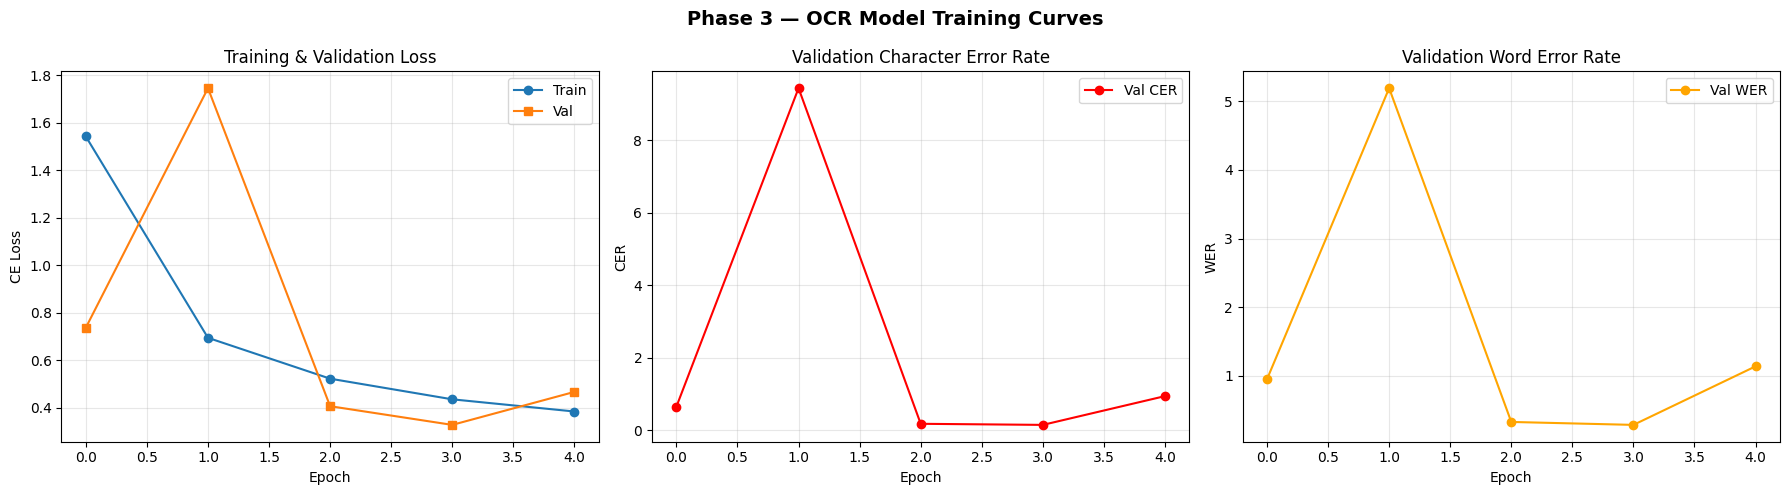

In [33]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(ocr_history['train_loss'], label='Train', marker='o')
axes[0].plot(ocr_history['val_loss'], label='Val', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('CE Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# CER
axes[1].plot(ocr_history['val_cer'], label='Val CER', color='red', marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('CER')
axes[1].set_title('Validation Character Error Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# WER
axes[2].plot(ocr_history['val_wer'], label='Val WER', color='orange', marker='o')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('WER')
axes[2].set_title('Validation Word Error Rate')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Phase 3 \u2014 OCR Model Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 3.6 — Beam Search Decoding Test

Run beam search on sample images and display decoded text vs ground truth.

Loaded best OCR model


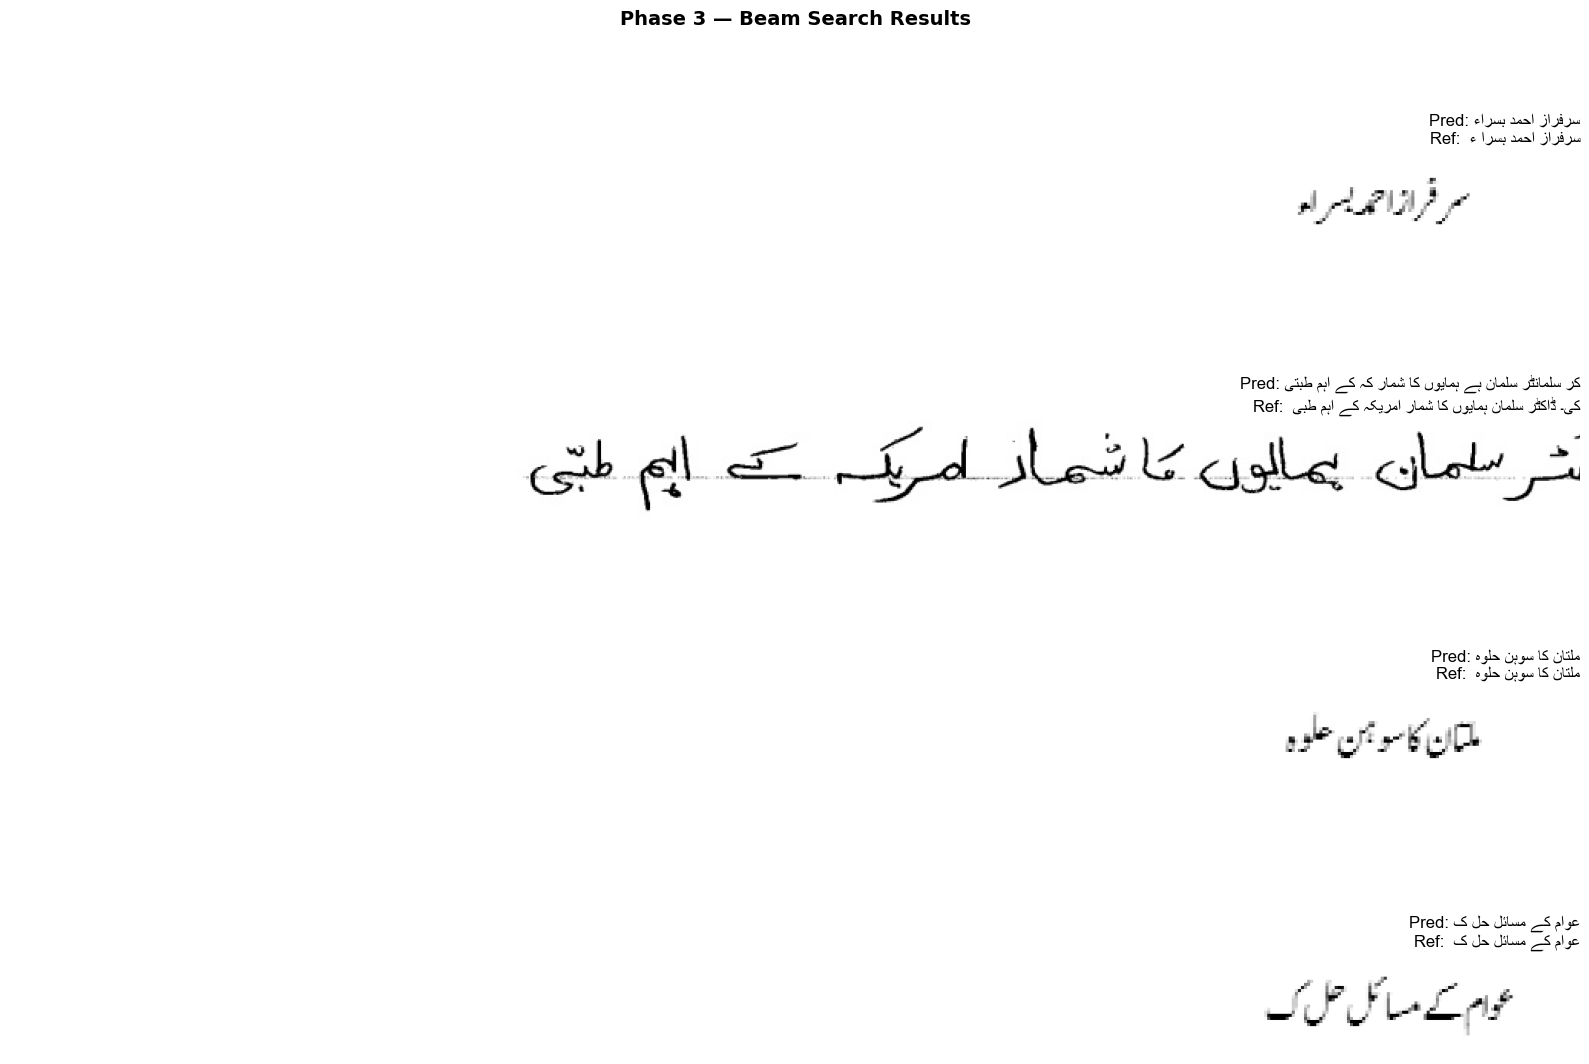

In [34]:
# Load best model for inference
import os
import arabic_reshaper
from bidi.algorithm import get_display

best_ocr_path = os.path.join('checkpoints', 'best_ocr_model.pth')
if os.path.exists(best_ocr_path):
    best_ocr = load_ocr_model(best_ocr_path, vocab.size, DEVICE)
    print('Loaded best OCR model')
else:
    best_ocr = ocr_model
    print('Using final training model')

# Beam search on test samples
test_imgs, test_labels, test_lens, _ = next(iter(ocr_loaders['test']))

N_BEAM = min(4, test_imgs.size(0))
fig, axes = plt.subplots(N_BEAM, 1, figsize=(16, N_BEAM * 3))
if N_BEAM == 1:
    axes = [axes]

for i in range(N_BEAM):
    img = test_imgs[i:i+1].to(DEVICE)
    ref_text = vocab.decode(test_labels[i].tolist())
    
    # Beam search
    beams = best_ocr.beam_search_decode(img, beam_width=5, max_len=200, alpha=0.7)
    pred_text = vocab.decode(beams[0][0])  # top beam
    
    # Fix RTL rendering for matplotlib
    ref_bidi = get_display(arabic_reshaper.reshape(ref_text))
    pred_bidi = get_display(arabic_reshaper.reshape(pred_text))
    
    axes[i].imshow(test_imgs[i].squeeze().numpy(), cmap='gray')
    axes[i].set_title(
        f'Pred: {pred_bidi}\nRef:  {ref_bidi}',
        fontsize=12, loc='right', fontfamily='Arial'
    )
    axes[i].axis('off')

fig.suptitle('Phase 3 \u2014 Beam Search Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 3.7 — Test Set Evaluation (CER & WER)

In [35]:
# Full test set evaluation
test_ocr_trainer = OCRTrainer(best_ocr, vocab, DEVICE)
test_metrics = test_ocr_trainer.validate(ocr_loaders['test'])

print(f'\n{"=" * 40}')
print(f'TEST SET RESULTS (OCR)')
print(f'{"=" * 40}')
print(f'CE Loss : {test_metrics["loss"]:.4f}')
print(f'CER     : {test_metrics["cer"]:.4f} ({test_metrics["cer"]*100:.2f}%)')
print(f'WER     : {test_metrics["wer"]:.4f} ({test_metrics["wer"]*100:.2f}%)')


TEST SET RESULTS (OCR)
CE Loss : 0.3165
CER     : 0.1469 (14.69%)
WER     : 0.2781 (27.81%)


---
### Phase 3 ✓ Complete

**What was done:**
1. Fixed label loading for both MMU-OCR-21 and UHWR datasets
2. Built character-level vocabulary (saved to `checkpoints/vocab.json`)
3. Created CNN backbone: 7 conv blocks, LeakyReLU + BatchNorm, seq_len=128, d_model=256
4. Verified CNN → Transformer shape alignment
5. Trained full Conv-Transformer (3 enc + 3 dec) with cross-entropy + Adam
6. Implemented beam search with length penalty (alpha=0.7)
7. Evaluated CER and WER on held-out test set
8. Models saved to `checkpoints/` for deployment

# Phase 4: Pipeline Integration & Inference
Let's test the complete end-to-end pipeline (Noisy Input -> SMP Restoration -> Conv-Transformer OCR -> Text Output).

Initializing Pipeline...


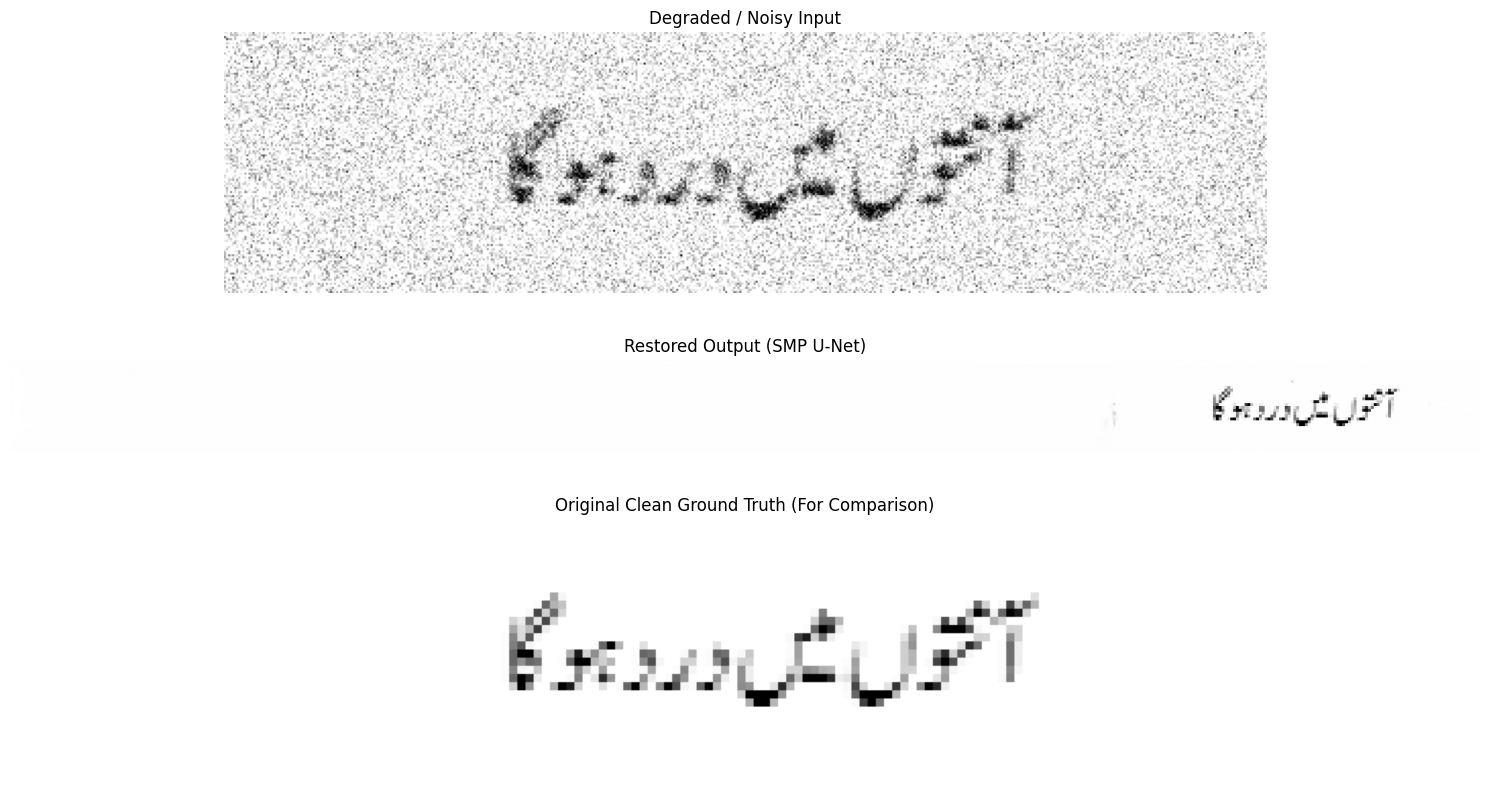

Ground Truth : ﺁﻧﺘﻮﮞ ﻣﯿﮟ ﺩﺭﺩ ﮨﻮﮔﺎ
Prediction   : ﺁﻧﺘﻮﮞ ﻣﯿﮟ ﺩﺭﺩ ﮨﻮﮔﺎ


In [36]:
import random
import cv2
import matplotlib.pyplot as plt
from IPython.display import display
import pandas as pd
import arabic_reshaper
from bidi.algorithm import get_display
from preprocessing import degrade_image, standardize_image
from models.pipeline import UrduOCRPipeline

# Initialize pipeline
print("Initializing Pipeline...")
pipeline = UrduOCRPipeline(
    restoration_ckpt="checkpoints/final_restoration_model.pth",
    ocr_ckpt="checkpoints/final_ocr_model.pth",
    vocab_path="checkpoints/vocab.json",
    device="cuda"
)

# Load a random image from the test set
df = pd.read_csv("splits/test.csv")
sample = df.sample(1).iloc[0]
img_path = sample["image_path"]
gt_label = sample["label"]

# Preprocess & Degrade to simulate real input
clean_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
clean_img = standardize_image(clean_img, 128)
degraded_img = degrade_image(clean_img)

# Run Pipeline
restored_img, predicted_text = pipeline.predict(degraded_img)

# Handle Arabic/Urdu RTL rendering for matplotlib
reshaped_gt = arabic_reshaper.reshape(str(gt_label))
reshaped_pred = arabic_reshaper.reshape(predicted_text)

fig, axes = plt.subplots(3, 1, figsize=(15, 8))
axes[0].imshow(degraded_img, cmap="gray")
axes[0].set_title("Degraded / Noisy Input")
axes[0].axis("off")

axes[1].imshow(restored_img, cmap="gray")
axes[1].set_title("Restored Output (SMP U-Net)")
axes[1].axis("off")

axes[2].imshow(clean_img, cmap="gray")
axes[2].set_title("Original Clean Ground Truth (For Comparison)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("Ground Truth :", reshaped_gt)
print("Prediction   :", reshaped_pred)


---
# Final Evaluation on Test Set (Best Model)

We now load the weights that achieved the lowest validation loss during training and evaluate them on the unseen test set.

In [1]:
import os
import torch
import pandas as pd
from torch.utils.data import DataLoader
from models.ocr_model import ConvTransformerOCR
from models.ocr_trainer import OCRTrainer
from models.vocab import Vocabulary
from datasets.ocr_dataset import get_ocr_dataloaders

# 1. Environment Setup
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TARGET_HEIGHT = 128
TARGET_WIDTH = 2048
DATASET_ROOT = os.getenv("DATASET_ROOT", "V:\\") # Update this if needed

print(f"Device: {DEVICE}")
print(f"Dataset Root: {DATASET_ROOT}")

# 2. Load Vocabulary
vocab_path = "checkpoints/vocab.json"
if os.path.exists(vocab_path):
    vocab = Vocabulary.load(vocab_path)
    print(f"Loaded vocabulary: {vocab.size} characters.")
else:
    raise FileNotFoundError(f"Required file {vocab_path} not found. Please ensure it exists.")

# 3. Load Best Model
best_model_path = "checkpoints/best_ocr_model.pth"
if not os.path.exists(best_model_path):
    print(f"Warning: {best_model_path} not found. Falling back to final_ocr_model.pth")
    best_model_path = "checkpoints/final_ocr_model.pth"

if not os.path.exists(best_model_path):
    raise FileNotFoundError("No model checkpoint found in checkpoints/ folder.")

model = ConvTransformerOCR(vocab_size=vocab.size, d_model=256).to(DEVICE)
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE, weights_only=True))
model.eval()
print(f"Model loaded from {best_model_path}")

# 4. Prepare Test Dataloader
print("Preparing test dataloader...")
ocr_loaders = get_ocr_dataloaders(
    vocab=vocab,
    data_dir=DATASET_ROOT,
    splits_dir='splits',
    target_height=TARGET_HEIGHT,
    target_width=TARGET_WIDTH,
    batch_size=16,
    num_workers=0 # Set to 0 for stability in self-contained cells
)
test_loader = ocr_loaders['test']

# 5. Run Evaluation
trainer = OCRTrainer(model, vocab, DEVICE)
print("Running full test set evaluation (this may take a minute)...\n")
test_metrics = trainer.validate(test_loader)

print(f"{'='*40}")
print(f"FINAL TEST SET METRICS")
print(f"{'='*40}")
print(f"Test Loss : {test_metrics['loss']:.4f}")
print(f"Test CER  : {test_metrics['cer']:.4f} ({test_metrics['cer']*100:.2f}%)")
print(f"Test WER  : {test_metrics['wer']:.4f} ({test_metrics['wer']*100:.2f}%)")
print(f"{'='*40}\n")

# 6. Show Sample Predictions
print("Sample Predictions:")
print("-" * 20)

with torch.no_grad():
    images, labels, lengths, weights = next(iter(test_loader))
    images = images.to(DEVICE)
    preds = trainer._greedy_decode(images)
    
    for i in range(min(10, len(images))):
        pred_text = vocab.decode(preds[i], strip_special=True)
        ref_text = vocab.decode(labels[i].tolist(), strip_special=True)
        print(f"Ref  : {ref_text}")
        print(f"Pred : {pred_text}")
        print("-" * 20)

Device: cuda
Dataset Root: V:\
Loaded vocabulary: 173 characters.
Model loaded from checkpoints/best_ocr_model.pth
Preparing test dataloader...
Running full test set evaluation (this may take a minute)...

FINAL TEST SET METRICS
Test Loss : 0.2075
Test CER  : 0.0814 (8.14%)
Test WER  : 0.1833 (18.33%)

Sample Predictions:
--------------------
Ref  : سرفراز احمد بسرا ء
Pred : سرفراز احمد بسراء )
--------------------
Ref  : کی۔ ڈاکٹر سلمان ہمایوں کا شمار امریکہ کے اہم طبی
Pred : اور سلمان بھالوں کا شمار لماد المریکہ کے ایم طبقی
--------------------
Ref  : ملتان کا سوہن حلوہ
Pred : ملتان کا سوہن حلوہ
--------------------
Ref  : عوام کے مسائل حل ک
Pred : عوام کے مسائل حل ک
--------------------
Ref  : ڈی آئی خان ہکلا
Pred : ڈی آئی خان ہلا
--------------------
Ref  : محمود حیات ٹوچی خان
Pred : محمود حیات ٹوچی خان
--------------------
Ref  : جس میں یورو گوائے
Pred : جس میں یو روگوائے
--------------------
Ref  : پی ٹی آئی رہنما او
Pred : پی ٹی آئی رہنما او
--------------------
Ref  : 17کے اخ

## UHWR (Handwritten) Specific Evaluation
This cell focuses only on the handwritten Urdu samples from the NUST-UHWR dataset.

Filtering test set for UHWR (Handwritten) samples...

Running UHWR specific predictions...


C:\Users\ashma\AppData\Local\Temp\ipykernel_7064\3080052443.py:59: UserWarning: Glyph 64431 (\N{ARABIC LETTER YEH BARREE FINAL FORM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ashma\AppData\Local\Temp\ipykernel_7064\3080052443.py:59: UserWarning: Glyph 64425 (\N{ARABIC LETTER HEH GOAL MEDIAL FORM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ashma\AppData\Local\Temp\ipykernel_7064\3080052443.py:59: UserWarning: Glyph 64423 (\N{ARABIC LETTER HEH GOAL FINAL FORM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ashma\AppData\Local\Temp\ipykernel_7064\3080052443.py:59: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ashma\AppData\Local\Temp\ipykernel_7064\3080052443.py:59: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
C:\Users\ashma\AppData\Local\Temp\ipykernel_7064\3080052443.py:59: UserWarning: Glyph 64424 (\N{ARABIC LETTER H

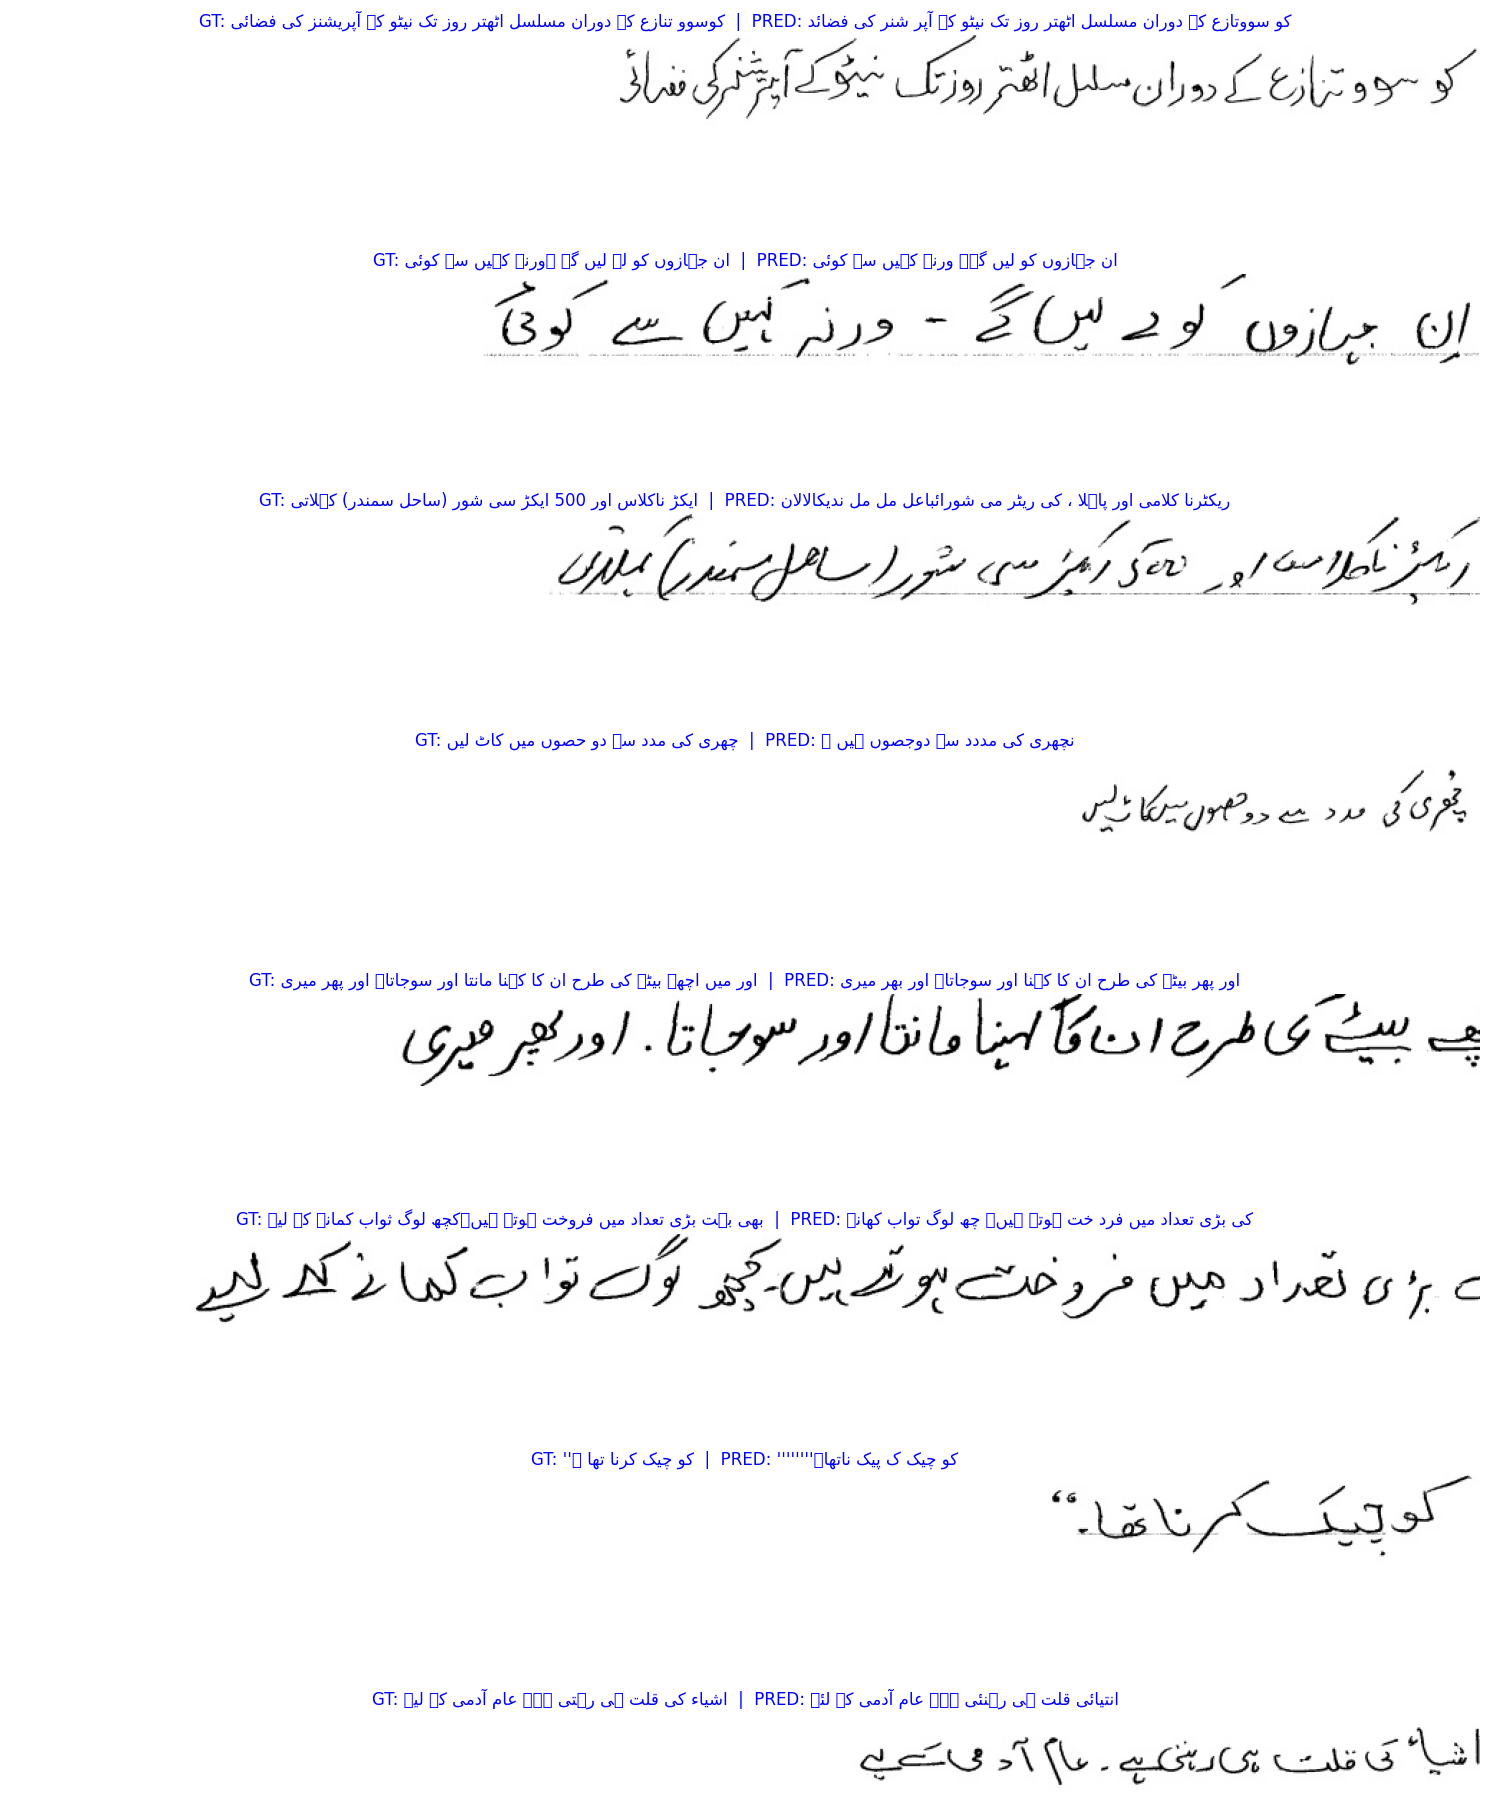


UHWR MINI-SAMPLE RESULTS
Sample CER : 0.2989 (29.89%)
Sample WER : 0.5529 (55.29%)


In [2]:
import matplotlib.pyplot as plt
import random
import cv2
import arabic_reshaper
from bidi.algorithm import get_display
from preprocessing import standardize_and_pad # Use the real one!

def format_urdu(text):
    if not text or not isinstance(text, str): return ""
    try:
        reshaped = arabic_reshaper.reshape(text)
        return get_display(reshaped)
    except:
        return text

print("Filtering test set for UHWR (Handwritten) samples...")
test_df = pd.read_csv('splits/test.csv')
uhwr_test_df = test_df[test_df['source'] == 'UHWR']

if len(uhwr_test_df) == 0:
    print("No UHWR samples found in test set!")
else:
    num_samples = min(8, len(uhwr_test_df))
    samples = uhwr_test_df.sample(num_samples)
    
    fig, axes = plt.subplots(num_samples, 1, figsize=(15, 2.5 * num_samples))
    if num_samples == 1: axes = [axes]
    
    all_preds = []
    all_refs = []
    
    print("\nRunning UHWR specific predictions...")
    for idx, (i, row) in enumerate(samples.iterrows()):
        img_path = row['image_path']
        ref_text = str(row['label'])
        
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        
        # USE THE REAL PREPROCESSING LOGIC (RTL padding, white background)
        img_final = standardize_and_pad(img, target_height=128, target_width=2048, pad_value=255)
            
        img_tensor = torch.from_numpy(img_final).float().unsqueeze(0).unsqueeze(0) / 255.0
        img_tensor = img_tensor.to(DEVICE)
        
        # Predict
        pred_indices = trainer._greedy_decode(img_tensor)
        pred_text = vocab.decode(pred_indices[0], strip_special=True)
        
        all_preds.append(pred_text)
        all_refs.append(ref_text)
        
        # Visualize
        axes[idx].imshow(img_final, cmap='gray')
        # Display GT and Pred in the title (RTL formatted)
        axes[idx].set_title(f"GT: {format_urdu(ref_text)}  |  PRED: {format_urdu(pred_text)}", fontsize=12, color='blue')
        axes[idx].axis('off')
        
    plt.tight_layout()
    plt.show()
    
    from models.ocr_trainer import compute_cer, compute_wer
    mini_cer = compute_cer(all_preds, all_refs)
    mini_wer = compute_wer(all_preds, all_refs)
    
    print(f"\n{'='*40}")
    print(f"UHWR MINI-SAMPLE RESULTS")
    print(f"{'='*40}")
    print(f"Sample CER : {mini_cer:.4f} ({mini_cer*100:.2f}%)")
    print(f"Sample WER : {mini_wer:.4f} ({mini_wer*100:.2f}%)")
    print(f"{'='*40}")


## 4.1 — Baseline Benchmarking: DL Model vs Tesseract

Compare our DL Model CER and WER against Tesseract OCR baseline on the test set.

In [5]:
import pytesseract
from tqdm import tqdm
import cv2
from models.ocr_trainer import compute_cer, compute_wer
from preprocessing import standardize_and_pad
import os
import torch
import pandas as pd
from torch.utils.data import DataLoader
from models.ocr_model import ConvTransformerOCR
from models.ocr_trainer import OCRTrainer
from models.vocab import Vocabulary
from datasets.ocr_dataset import get_ocr_dataloaders

# 1. Environment Setup
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TARGET_HEIGHT = 128
TARGET_WIDTH = 2048
DATASET_ROOT = os.getenv("DATASET_ROOT", "V:\\")

print(f"Device: {DEVICE}")
print(f"Dataset Root: {DATASET_ROOT}")

# 2. Load Vocabulary
vocab_path = "checkpoints/vocab.json"
if os.path.exists(vocab_path):
    vocab = Vocabulary.load(vocab_path)
    print(f"Loaded vocabulary: {vocab.size} characters.")
else:
    raise FileNotFoundError(f"Required file {vocab_path} not found. Please ensure it exists.")

# 3. Load Best Model
best_model_path = "checkpoints/best_ocr_model.pth"
if not os.path.exists(best_model_path):
    print(f"Warning: {best_model_path} not found. Falling back to final_ocr_model.pth")
    best_model_path = "checkpoints/final_ocr_model.pth"

if not os.path.exists(best_model_path):
    raise FileNotFoundError("No model checkpoint found in checkpoints/ folder.")

model = ConvTransformerOCR(vocab_size=vocab.size, d_model=256).to(DEVICE)
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE, weights_only=True))
model.eval()
print(f"Model loaded from {best_model_path}")

# 4. Prepare Test Dataloader
print("Preparing test dataloader...")
ocr_loaders = get_ocr_dataloaders(
    vocab=vocab,
    data_dir=DATASET_ROOT,
    splits_dir='splits',
    target_height=TARGET_HEIGHT,
    target_width=TARGET_WIDTH,
    batch_size=16,
    num_workers=0
)
test_loader = ocr_loaders['test']

# 5. Run Evaluation
trainer = OCRTrainer(model, vocab, DEVICE)

pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

print("Benchmarking DL Model vs Tesseract on Test Set...")

test_df = pd.read_csv('splits/test.csv')
eval_subset = test_df.sample(min(50, len(test_df)), random_state=42)

model_preds = []
tesseract_preds = []
ground_truths = []

for _, row in tqdm(eval_subset.iterrows(), total=len(eval_subset)):
    img_path = row['image_path']
    gt_label = str(row['label'])

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: continue

    # FIX: Tesseract gets the raw image, not the DL-padded version
    tess_text = pytesseract.image_to_string(img, config='--psm 7', lang='urd').strip()

    # DL model gets the padded/preprocessed version
    img_final = standardize_and_pad(img, target_height=128, target_width=2048, pad_value=255)
    img_tensor = torch.from_numpy(img_final).float().unsqueeze(0).unsqueeze(0) / 255.0
    img_tensor = img_tensor.to(DEVICE)

    pred_indices = trainer._greedy_decode(img_tensor)
    pred_text = vocab.decode(pred_indices[0], strip_special=True)

    model_preds.append(pred_text)
    tesseract_preds.append(tess_text)
    ground_truths.append(gt_label)

def calc_metrics(preds, gts):
    total_cer = sum(compute_cer([p], [g]) for p, g in zip(preds, gts)) / len(gts)
    total_wer = sum(compute_wer([p], [g]) for p, g in zip(preds, gts)) / len(gts)
    return total_cer, total_wer

mod_cer, mod_wer = calc_metrics(model_preds, ground_truths)
tess_cer, tess_wer = calc_metrics(tesseract_preds, ground_truths)

print("\n" + "="*50)
print(" BENCHMARKING RESULTS (CER / WER) ")
print("="*50)
print(f"Tesseract Baseline:")
print(f"  CER: {tess_cer:.4f} ({tess_cer*100:.2f}%)")
print(f"  WER: {tess_wer:.4f} ({tess_wer*100:.2f}%)")
print("-" * 50)
print(f"Our DL Model:")
print(f"  CER: {mod_cer:.4f} ({mod_cer*100:.2f}%)")
print(f"  WER: {mod_wer:.4f} ({mod_wer*100:.2f}%)")
print("="*50)

Device: cuda
Dataset Root: V:\
Loaded vocabulary: 173 characters.
Model loaded from checkpoints/best_ocr_model.pth
Preparing test dataloader...
Benchmarking DL Model vs Tesseract on Test Set...


100%|██████████| 50/50 [00:09<00:00,  5.12it/s]



 BENCHMARKING RESULTS (CER / WER) 
Tesseract Baseline:
  CER: 0.6204 (62.04%)
  WER: 0.9315 (93.15%)
--------------------------------------------------
Our DL Model:
  CER: 0.0375 (3.75%)
  WER: 0.1032 (10.32%)
